# EDA - Christoph

# EDA Layers for Electricity Price Forecasting (BESS Optimization)

---

## Layer 1 — Data Inventory & Health Check
*"What do we have?"*

- Shape, column names, dtypes
- Missing values — how many, where, any patterns?
- Duplicates
- Date range and frequency (hourly? 15-min?)

---

## Layer 2 — Target Variable Deep Dive
*"Understand what we're forecasting"*

- Distribution of electricity prices (skew, outliers, negative prices — very common in Germany!)
- Price spikes and their magnitude
- Summary statistics (mean, median, std, percentiles)

---

## Layer 3 — Time Structure Analysis
*"Electricity is all about time patterns"*

- Hourly, daily, weekly, monthly, seasonal patterns
- Year-over-year trends
- Regime changes (e.g. post-2021 energy crisis)
- Autocorrelation (ACF/PACF) — how much does yesterday predict today?

---

## Layer 4 — Feature Distributions & Quality
*"Are our input signals clean and usable?"*

- Distribution of each feature (renewables, load, gas prices, etc.)
- Outliers per feature
- Zero/negative values where unexpected

---

## Layer 5 — Correlation & Relationships
*"What actually drives the price?"*

- Correlation matrix of all features vs. price
- Scatter plots of key drivers (wind, solar, gas) vs. price
- Non-linear relationships

---

## Layer 6 — Temporal Feature Relationships
*"Do drivers behave differently at different times?"*

- Price vs. solar generation by hour-of-day
- Price vs. load by season
- Residual demand (load minus renewables) — the key BESS signal

---

## Layer 7 — Stationarity & Forecast Readiness
*"Is the data ready for an ML model?"*

- Stationarity tests (ADF test)
- Lag feature potential
- Train/validation split sanity check — no data leakage

---


In [1]:
# Import pandas for loading and working with tabular data
import pandas as pd

# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns


##Set plotting options for the notebook
# Use a clean seaborn style for plots
sns.set_style("whitegrid")

# Set a default figure size for matplotlib plots
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Read the final engineered dataset from the data folder
df_final = pd.read_csv("../data/df_final.csv", parse_dates=["timestamp"])

In [7]:
df_final.columns

Index(['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
       'hour', 'day_of_week', 'month', 'temperature', 'wind_speed',
       'is_weekend', 'co2_price', 'total_generation', 'net_export',
       'actual_load'],
      dtype='object')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['figure.dpi'] = 100

1.1 SHAPE & COLUMN OVERVIEW
Rows: 62,945  |  Columns: 16

Column names and dtypes:
timestamp           datetime64[ns]
price                      float64
load                       float64
wind_offshore              float64
wind_onshore               float64
solar                      float64
hour                         int64
day_of_week                  int64
month                        int64
temperature                float64
wind_speed                 float64
is_weekend                    bool
co2_price                  float64
total_generation           float64
net_export                 float64
actual_load                float64

1.2 SAMPLE PEEK (first 3 & last 3 rows)


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,co2_price,total_generation,net_export,actual_load
0,2019-01-01 00:00:00,28.32,43213.25,5069.00,18879.75,0.0,0,1,1,6.3750,27.820704,False,23.01,53298.00,NaN,43273.75
1,2019-01-01 01:00:00,10.07,41275.75,5042.25,20626.50,0.0,1,1,1,6.3375,29.881138,False,23.01,52618.00,NaN,41631.25
2,2019-01-01 02:00:00,-4.08,40187.50,5028.50,22355.50,0.0,2,1,1,6.2625,32.079460,False,23.01,51990.25,NaN,40085.00


,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,wind_speed,is_weekend,co2_price,total_generation,net_export,actual_load
62942,2026-03-05 20:00:00,135.25,61639.86,3770.35,17757.48,0.0,20,3,3,7.550000,23.550648,False,82.25,60044.93,2810.27,60565.71
62943,2026-03-05 21:00:00,130.59,58043.48,3633.21,17964.93,0.0,21,3,3,6.825000,22.557327,False,82.25,58359.74,3755.56,57190.45
62944,2026-03-05 22:00:00,130.14,54547.59,3259.55,16587.78,0.0,22,3,3,6.099999,21.846586,False,82.25,55448.25,4355.30,53594.19



1.3 MISSING VALUES
            missing_count  missing_%
net_export          15205      24.16


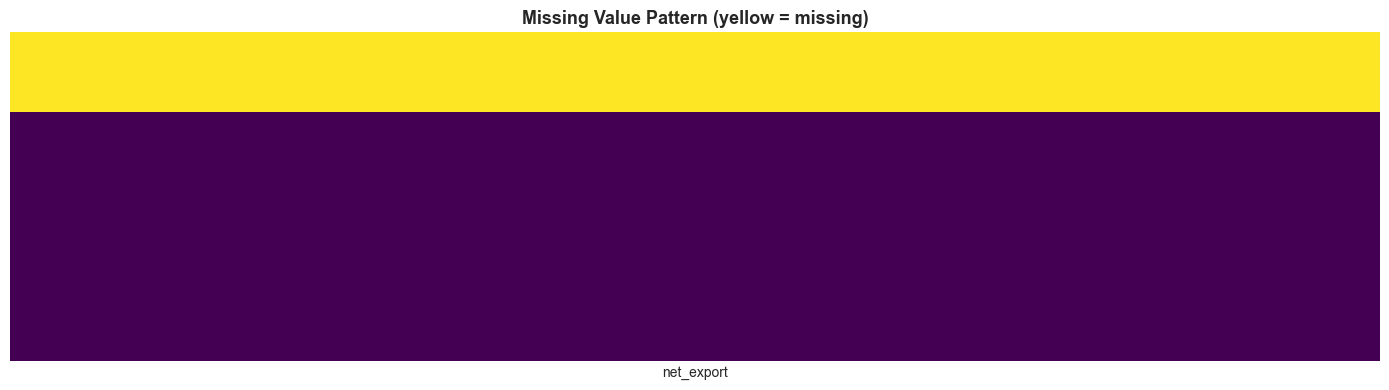


1.4 DUPLICATE ROWS
Total duplicate rows: 0
Duplicate timestamps in 'timestamp': 49
                timestamp
7177  2019-10-27 02:00:00
7178  2019-10-27 02:00:00
7179  2019-10-27 02:00:00
7180  2019-10-27 02:00:00
7181  2019-10-27 02:00:00
7182  2019-10-27 02:00:00
7183  2019-10-27 02:00:00
7184  2019-10-27 02:00:00
15919 2020-10-25 02:00:00
15920 2020-10-25 02:00:00

1.5 DATE RANGE & FREQUENCY
Column     : timestamp
Start      : 2019-01-01 00:00:00
End        : 2026-03-05 22:00:00
Total span : 2620 days 22:00:00

Top timestamp intervals (value_counts):
timestamp
0 days 01:00:00    62888
0 days 00:00:00       49
0 days 02:00:00        7

→ Dominant interval: 0 days 01:00:00
→ Expected timestamps : 62,903
→ Actual timestamps   : 62,945
→ Missing timestamps  : 7

First 10 missing timestamps:
[Timestamp('2019-03-31 02:00:00'), Timestamp('2020-03-29 02:00:00'), Timestamp('2021-03-28 02:00:00'), Timestamp('2022-03-27 02:00:00'), Timestamp('2023-03-26 02:00:00'), Timestamp('2024-03-31 02:00:

,count,mean,min,1%,5%,25%,50%,75%,95%,99%,max,std
timestamp,62945,2022-08-03 12:56:22.896178944,2019-01-01 00:00:00,2019-01-27 05:26:24,2019-05-12 04:12:00,2020-10-17 11:00:00,2022-08-03 15:00:00,2024-05-19 19:00:00,2025-10-26 01:48:00,2026-02-07 16:33:36,2026-03-05 22:00:00,NaN
price,62945.0,94.919403,-500.0,-9.9556,2.244,38.08,75.58,115.07,277.91,480.0,936.28,92.820339
load,62945.0,54281.186015,30544.75,36266.44,39862.0,46783.5,54158.75,61852.75,68757.676,71478.31,77585.75,9182.981115
wind_offshore,62945.0,2903.732465,13.0,91.0,272.75,1158.75,2754.5,4586.25,5894.25,6394.53,7344.19,1885.232424
wind_onshore,62945.0,11959.632699,161.25,745.61,1609.25,4608.75,9203.75,17012.25,31857.982,39328.33,46617.25,9406.575822
solar,62945.0,6159.282226,0.0,0.0,0.0,0.0,209.5,9682.5,27658.5,37390.2,50444.75,9591.063234
hour,62945.0,11.493478,0.0,0.0,1.0,5.0,11.0,17.0,22.0,23.0,23.0,6.924182
day_of_week,62945.0,3.000858,0.0,0.0,0.0,1.0,3.0,5.0,6.0,6.0,6.0,2.000198
month,62945.0,6.40537,1.0,1.0,1.0,3.0,6.0,9.0,12.0,12.0,12.0,3.491876
temperature,62945.0,10.647097,-10.762501,-3.7945,-0.6375,4.775,10.162499,16.2875,23.247499,27.7,35.6375,7.496863


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# ─────────────────────────────────────────────
# LAYER 1 — DATA INVENTORY & HEALTH CHECK
# ─────────────────────────────────────────────

# ── 1.1 Shape & Column Overview ──────────────
print("=" * 60)
print("1.1 SHAPE & COLUMN OVERVIEW")
print("=" * 60)
print(f"Rows: {df_final.shape[0]:,}  |  Columns: {df_final.shape[1]}")
print("\nColumn names and dtypes:")
print(df_final.dtypes.to_string())

# ── 1.2 Sample Peek ───────────────────────────
print("\n" + "=" * 60)
print("1.2 SAMPLE PEEK (first 3 & last 3 rows)")
print("=" * 60)
display(df_final.head(3))
display(df_final.tail(3))

# ── 1.3 Missing Values ────────────────────────
print("\n" + "=" * 60)
print("1.3 MISSING VALUES")
print("=" * 60)
missing = pd.DataFrame({
    "missing_count": df_final.isnull().sum(),
    "missing_%": (df_final.isnull().sum() / len(df_final) * 100).round(2)
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_%", ascending=False)

if missing.empty:
    print("✅ No missing values found.")
else:
    print(missing.to_string())
    # Heatmap of missingness
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(df_final[missing.index].isnull(),
                yticklabels=False, cbar=False, cmap="viridis", ax=ax)
    ax.set_title("Missing Value Pattern (yellow = missing)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ── 1.4 Duplicates ────────────────────────────
print("\n" + "=" * 60)
print("1.4 DUPLICATE ROWS")
print("=" * 60)
n_dupes = df_final.duplicated().sum()
print(f"Total duplicate rows: {n_dupes}")

# Check for duplicate timestamps if a datetime column exists
dt_cols = df_final.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
if dt_cols:
    for col in dt_cols:
        n_ts_dupes = df_final[col].duplicated().sum()
        print(f"Duplicate timestamps in '{col}': {n_ts_dupes}")
        if n_ts_dupes > 0:
            print(df_final[df_final[col].duplicated(keep=False)][[col]].head(10))
else:
    print("⚠️  No datetime column detected — check if timestamp is stored as string.")

# ── 1.5 Date Range & Frequency ───────────────
print("\n" + "=" * 60)
print("1.5 DATE RANGE & FREQUENCY")
print("=" * 60)
if dt_cols:
    for col in dt_cols:
        ts = df_final[col].sort_values()
        print(f"Column     : {col}")
        print(f"Start      : {ts.min()}")
        print(f"End        : {ts.max()}")
        print(f"Total span : {ts.max() - ts.min()}")
        # Infer frequency
        diffs = ts.diff().dropna().value_counts()
        print(f"\nTop timestamp intervals (value_counts):")
        print(diffs.head(5).to_string())
        dominant_freq = diffs.idxmax()
        print(f"\n→ Dominant interval: {dominant_freq}")
        # Check for gaps
        expected = pd.date_range(start=ts.min(), end=ts.max(), freq=dominant_freq)
        missing_ts = expected.difference(ts)
        print(f"→ Expected timestamps : {len(expected):,}")
        print(f"→ Actual timestamps   : {len(ts):,}")
        print(f"→ Missing timestamps  : {len(missing_ts):,}")
        if len(missing_ts) > 0:
            print("\nFirst 10 missing timestamps:")
            print(missing_ts[:10].tolist())
else:
    print("⚠️  No datetime column found — skipping date range check.")

# ── 1.6 Basic Statistics Summary ─────────────
print("\n" + "=" * 60)
print("1.6 BASIC STATISTICS (numeric columns)")
print("=" * 60)
display(df_final.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

In [5]:
### 1.3 Duplicates & Time Gaps

# Duplicate timestamps
dupes = df_final.duplicated(subset='timestamp').sum()
print(f"Duplicate timestamps: {dupes}")

# Missing hours
full_range = pd.date_range(df_final['timestamp'].min(), df_final['timestamp'].max(), freq='h')
missing_hours = full_range.difference(df_final['timestamp'])
print(f"Missing hours: {len(missing_hours)}")
if len(missing_hours) > 0 and len(missing_hours) <= 20:
    print(missing_hours.tolist())
elif len(missing_hours) > 20:
    print(f"First 10: {missing_hours[:10].tolist()}")

Duplicate timestamps: 49
Missing hours: 7
[Timestamp('2019-03-31 02:00:00'), Timestamp('2020-03-29 02:00:00'), Timestamp('2021-03-28 02:00:00'), Timestamp('2022-03-27 02:00:00'), Timestamp('2023-03-26 02:00:00'), Timestamp('2024-03-31 02:00:00'), Timestamp('2025-03-30 02:00:00')]


In [6]:
### 1.5 Plausibility Checks

print("=== Plausibility Checks ===")
print(f"Negative prices: {(df_final['price'] < 0).sum()} ({(df_final['price'] < 0).mean()*100:.1f}%)")
print(f"Price min: {df_final['price'].min():.2f}, max: {df_final['price'].max():.2f}")
print(f"Load min: {df_final['load'].min():.0f}, max: {df_final['load'].max():.0f}")
print(f"Temperature min: {df_final['temperature'].min():.1f}, max: {df_final['temperature'].max():.1f}")
print(f"Gas price min: {df_final['gas_price'].min():.2f}, max: {df_final['gas_price'].max():.2f}")

# Check for zeros that shouldn't be zero
for col in ['load', 'total_generation']:
    zeros = (df_final[col] == 0).sum()
    if zeros > 0:
        print(f"⚠️  {col} has {zeros} zero values — investigate!")

=== Plausibility Checks ===
Negative prices: 2067 (3.3%)
Price min: -500.00, max: 936.28
Load min: 30545, max: 77586
Temperature min: -10.8, max: 35.6


KeyError: 'gas_price'

In [ ]:

# ─────────────────────────────────────────────
# LAYER 2 — TARGET VARIABLE DEEP DIVE
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats


TARGET = "price"
TS     = "timestamp"

# ── 2.1 Extended Summary Statistics ──────────
print("=" * 60)
print("2.1 EXTENDED SUMMARY STATISTICS")
print("=" * 60)
s = df_final[TARGET]
summary = pd.Series({
    "count"       : s.count(),
    "mean"        : s.mean(),
    "median"      : s.median(),
    "std"         : s.std(),
    "min"         : s.min(),
    "1%"          : s.quantile(0.01),
    "5%"          : s.quantile(0.05),
    "25%"         : s.quantile(0.25),
    "75%"         : s.quantile(0.75),
    "95%"         : s.quantile(0.95),
    "99%"         : s.quantile(0.99),
    "max"         : s.max(),
    "skewness"    : s.skew(),
    "kurtosis"    : s.kurtosis(),
})
print(summary.to_string())

# ── 2.2 Negative Prices ───────────────────────
print("\n" + "=" * 60)
print("2.2 NEGATIVE PRICES")
print("=" * 60)
neg = df_final[df_final[TARGET] < 0]
print(f"Count of negative prices : {len(neg):,}")
print(f"% of all observations    : {len(neg)/len(df_final)*100:.2f}%")
if len(neg) > 0:
    print(f"Most negative price      : {neg[TARGET].min():.2f}")
    print(f"Mean negative price      : {neg[TARGET].mean():.2f}")
    print(f"\nNegative prices by year:")
    print(neg.groupby(df_final.loc[neg.index, TS].dt.year)[TARGET]
            .agg(["count", "min", "mean"])
            .rename(columns={"count":"n_negative","min":"most_negative","mean":"avg_negative"})
            .to_string())

# ── 2.3 Price Spikes ──────────────────────────
print("\n" + "=" * 60)
print("2.3 PRICE SPIKES (above 99th percentile)")
print("=" * 60)
spike_threshold = s.quantile(0.99)
spikes = df_final[df_final[TARGET] > spike_threshold]
print(f"Spike threshold (99th pct): {spike_threshold:.2f}")
print(f"Count of spikes           : {len(spikes):,}")
print(f"% of all observations     : {len(spikes)/len(df_final)*100:.2f}%")
print(f"Max spike                 : {spikes[TARGET].max():.2f}")
print(f"Mean spike value          : {spikes[TARGET].mean():.2f}")
print(f"\nSpikes by year:")
print(spikes.groupby(df_final.loc[spikes.index, TS].dt.year)[TARGET]
        .agg(["count", "max", "mean"])
        .rename(columns={"count":"n_spikes","max":"max_price","mean":"avg_spike"})
        .to_string())

# ── 2.4 Distribution Plot ─────────────────────
print("\n" + "=" * 60)
print("2.4 DISTRIBUTION & BOXPLOT")
print("=" * 60)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(s, bins=100, color="#2196F3", edgecolor="white", linewidth=0.3)
axes[0].axvline(s.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean: {s.mean():.1f}")
axes[0].axvline(s.median(), color="orange", linestyle="--", linewidth=1.5, label=f"Median: {s.median():.1f}")
axes[0].axvline(0,          color="black",  linestyle="-",  linewidth=1.0, label="Zero")
axes[0].set_title("Price Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Price (€/MWh)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
axes[1].boxplot(s.dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#2196F3", alpha=0.6),
                medianprops=dict(color="red", linewidth=2))
axes[1].axhline(0, color="black", linestyle="-", linewidth=1.0, label="Zero")
axes[1].set_title("Price Boxplot", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Price (€/MWh)")
axes[1].legend()

plt.suptitle("Layer 2 — Target Variable Distribution", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 2.5 Full Price Time Series ────────────────
print("\n" + "=" * 60)
print("2.5 FULL PRICE TIME SERIES")
print("=" * 60)
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_final[TS], df_final[TARGET], linewidth=0.5, color="#2196F3", alpha=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=1.0, label="Zero price")
ax.fill_between(df_final[TS], df_final[TARGET], 0,
                where=(df_final[TARGET] < 0),
                color="red", alpha=0.3, label="Negative price zones")
ax.set_title("Electricity Price — Full History", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Price (€/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 2.6 Rolling Volatility ────────────────────
print("\n" + "=" * 60)
print("2.6 ROLLING VOLATILITY (30-day rolling std)")
print("=" * 60)
df_plot = df_final[[TS, TARGET]].copy().set_index(TS).sort_index()
# Infer hourly → 30 days = 720 observations
rolling_std = df_plot[TARGET].rolling(window=720, min_periods=168).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(df_plot.index, df_plot[TARGET],
             linewidth=0.5, color="#2196F3", alpha=0.8)
axes[0].set_title("Price", fontsize=12, fontweight="bold")
axes[0].set_ylabel("€/MWh")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)

axes[1].plot(rolling_std.index, rolling_std,
             linewidth=1.0, color="#FF5722", alpha=0.9)
axes[1].set_title("30-Day Rolling Volatility (std)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Std Dev (€/MWh)")
axes[1].set_xlabel("Date")

plt.suptitle("Layer 2 — Price Level & Volatility Over Time",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Skewness: 2.54 & Kurtosis: 9.35 — What This Means

---

### Skewness: 2.54 — "The distribution has a long right tail"

Skewness measures **asymmetry** around the mean.

- A perfectly symmetric distribution (like a textbook bell curve) has skewness = 0
- **Positive skewness** means the right tail is longer — most prices cluster on the lower end, but there are extreme high values pulling the mean upward
- At **2.54** this is strongly positive — your price spikes (the 99th percentile values you saw in 2.3) are the culprit

**In plain English:** Most hours have moderate prices, but a meaningful number of hours have very high prices that stretch the distribution rightward. The mean is being pulled above the median because of these spikes.

---

### Kurtosis: 9.35 — "Extreme values occur far more often than a normal distribution would predict"

Kurtosis measures **tail heaviness** relative to a normal distribution.

- A normal distribution has kurtosis = 3 (some libraries report this as 0 after subtracting 3)
- **Above 3 means fat tails** — extreme events happen more frequently than normal
- At **9.35** this is very fat-tailed — roughly 3× heavier tails than normal

**In plain English:** Price spikes and deep negative prices are not rare accidents — they are a **structural feature** of the German electricity market. The grid reacts violently to supply/demand imbalances.

---

### Why This Matters for Your Project

| Implication | Detail |
|---|---|
| **Model choice** | Linear models will struggle — they assume normality. Tree-based models (XGBoost, LightGBM) handle fat tails better |
| **Loss function** | MAE is more robust than RMSE here — squaring errors in RMSE gives enormous weight to spikes, distorting training |
| **BESS opportunity** | Those fat tails are exactly where the money is — your model needs to capture spikes and negative prices well, not just the average |
| **Possible transformation** | You may want to consider log-transforming or winsorizing prices for some models, then back-transforming predictions |

---
The short version: your price distribution behaves like electricity markets always do — **mostly calm, occasionally extreme**. Your model needs to respect that. 

## Skewness — "Which way does the tail drag?"

Imagine you run a small food stand at a market. At the end of each day you count your revenue. Most days you make around €200. Occasionally you have a terrible day (€50), and very rarely you have a fantastic day (€800 when a bus tour stops by).

If you drew a histogram of all your daily revenues, the picture would not be symmetric. The left side (bad days) is fairly close to your typical day, but the right side has a long tail stretching toward those rare great days. That long right tail is **positive skewness**.

**Your electricity prices have skewness = +2.54.** This means:
- Most hours cluster around a fairly normal price (€60–100)
- There is a short left tail (negative prices, but they hit a floor around -€500)
- There is a very long right tail — rare but extreme spikes to €800+

A rule of thumb: above ±1 is meaningfully skewed, above ±2 is strongly skewed. At 2.54 your distribution is pulled hard to the right.

---

## Kurtosis — "How explosive are the extremes?"

Now imagine two different dice games.

**Game A** — Normal die: you roll a standard die, outcomes 1–6, fairly spread out, nothing dramatic. This is what a normal distribution looks like — moderate tails, moderate extremes.

**Game B** — Spike die: 95% of the time you roll and get a 3 (boring, nothing happens). But 5% of the time the die explodes and gives you either 1 or 100. Most rolls are completely unremarkable, but when something happens, it really happens.

**Kurtosis measures how much your distribution behaves like Game B** — how fat and heavy the tails are compared to a normal distribution. A normal distribution has kurtosis = 3 (sometimes reported as 0 after subtracting 3, called "excess kurtosis"). 

**Your electricity prices have kurtosis = 9.35** — extremely fat tails. In practical terms:

- The typical hour is fairly predictable and clustered near the median
- But when prices move, they can move *violently* — the crisis spikes of €800+ and the negative price hours of -€500 are far more common than a normal distribution would ever predict

This is exactly why using RMSE as your loss function would be dangerous — those extreme tail events would dominate the error calculation and distort your model toward fitting the spikes rather than getting typical hours right.

---

## A single intuitive picture

Think of three sand piles:

```
Normal distribution       Your price distribution
(low kurtosis)            (high kurtosis = 9.35)

      ████                        ██
     ██████                      ████
    ████████        vs.          ██████ ░░░░░░░░░░░░░░░░░░░░░░
   ██████████                   ████████
──────────────              ──────────────────────────────────
  Tails thin out              Tall narrow peak, but tails
  gradually                   extend FAR into extremes
```

High kurtosis = a distribution that is simultaneously **more boring in the middle** (prices cluster tightly around typical values) and **more dangerous at the edges** (when a spike happens, it is far larger than you would expect). 

For your BESS model this combination — rightward skew + fat tails — is actually the *signal you are trying to capture*. The negative price hours (left tail) are your charging opportunities, and the spike hours (right tail) are your discharge opportunities. They are rare, but they are where most of the arbitrage profit lives.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ─────────────────────────────────────────────
# LAYER 3 — TIME STRUCTURE ANALYSIS
# ─────────────────────────────────────────────

TARGET = "price"
TS     = "timestamp"

# Prepare time features
df = df_final[[TS, TARGET]].copy().sort_values(TS)
df["hour"]       = df[TS].dt.hour
df["dayofweek"]  = df[TS].dt.dayofweek          # 0=Monday, 6=Sunday
df["month"]      = df[TS].dt.month
df["year"]       = df[TS].dt.year
df["dayname"]    = df[TS].dt.day_name()
df["monthname"]  = df[TS].dt.month_name()

DAY_ORDER   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

# ── 3.1 Hourly Pattern ────────────────────────
print("=" * 60)
print("3.1 AVERAGE PRICE BY HOUR OF DAY")
print("=" * 60)
hourly = df.groupby("hour")[TARGET].agg(["mean","median","std"]).reset_index()
print(hourly.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(hourly["hour"], hourly["mean"],   color="#2196F3", linewidth=2.5, label="Mean")
ax.plot(hourly["hour"], hourly["median"], color="#FF5722", linewidth=2.0,
        linestyle="--", label="Median")
ax.fill_between(hourly["hour"],
                hourly["mean"] - hourly["std"],
                hourly["mean"] + hourly["std"],
                alpha=0.15, color="#2196F3", label="±1 Std Dev")
ax.axhline(0, color="black", linestyle="-", linewidth=0.8)
ax.set_xticks(range(24))
ax.set_title("Average Price by Hour of Day", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Price (€/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3.2 Day of Week Pattern ───────────────────
print("\n" + "=" * 60)
print("3.2 AVERAGE PRICE BY DAY OF WEEK")
print("=" * 60)
daily = df.groupby("dayname")[TARGET].agg(["mean","median","std"]).reindex(DAY_ORDER)
print(daily.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(daily.index, daily["mean"], color="#2196F3", alpha=0.8, edgecolor="white")
ax.errorbar(daily.index, daily["mean"], yerr=daily["std"],
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.axhline(df[TARGET].mean(), color="red", linestyle="--",
           linewidth=1.5, label=f"Overall mean: {df[TARGET].mean():.1f}")
ax.set_title("Average Price by Day of Week", fontsize=13, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Price (€/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3.3 Monthly & Seasonal Pattern ───────────
print("\n" + "=" * 60)
print("3.3 AVERAGE PRICE BY MONTH")
print("=" * 60)
monthly = df.groupby("monthname")[TARGET].agg(["mean","median","std"]).reindex(MONTH_ORDER)
print(monthly.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(monthly.index, monthly["mean"], color="#2196F3", alpha=0.8, edgecolor="white")
ax.errorbar(monthly.index, monthly["mean"], yerr=monthly["std"],
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.axhline(df[TARGET].mean(), color="red", linestyle="--",
           linewidth=1.5, label=f"Overall mean: {df[TARGET].mean():.1f}")
ax.set_title("Average Price by Month", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Price (€/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

# ── 3.4 Year-over-Year Trend ──────────────────
print("\n" + "=" * 60)
print("3.4 AVERAGE PRICE BY YEAR")
print("=" * 60)
yearly = df.groupby("year")[TARGET].agg(["mean","median","std","min","max"])
print(yearly.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly.index.astype(str), yearly["mean"],
       color="#2196F3", alpha=0.8, edgecolor="white")
ax.errorbar(yearly.index.astype(str), yearly["mean"], yerr=yearly["std"],
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.set_title("Average Price by Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Price (€/MWh)")
plt.tight_layout()
plt.show()

# ── 3.5 Heatmap — Hour vs Day of Week ─────────
print("\n" + "=" * 60)
print("3.5 HEATMAP — HOUR OF DAY vs DAY OF WEEK")
print("=" * 60)
pivot_dow = df.pivot_table(values=TARGET, index="hour",
                           columns="dayname", aggfunc="mean")[DAY_ORDER]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_dow, cmap="RdYlGn", ax=ax, linewidths=0.3,
            fmt=".0f", annot=True, annot_kws={"size": 8},
            cbar_kws={"label": "Avg Price (€/MWh)"})
ax.set_title("Average Price — Hour of Day vs Day of Week",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.show()

# ── 3.6 Heatmap — Hour vs Month ───────────────
print("\n" + "=" * 60)
print("3.6 HEATMAP — HOUR OF DAY vs MONTH")
print("=" * 60)
pivot_month = df.pivot_table(values=TARGET, index="hour",
                             columns="monthname", aggfunc="mean")[MONTH_ORDER]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot_month, cmap="RdYlGn", ax=ax, linewidths=0.3,
            fmt=".0f", annot=True, annot_kws={"size": 8},
            cbar_kws={"label": "Avg Price (€/MWh)"})
ax.set_title("Average Price — Hour of Day vs Month",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.show()

# ── 3.7 ACF & PACF ────────────────────────────
print("\n" + "=" * 60)
print("3.7 AUTOCORRELATION (ACF) & PARTIAL AUTOCORRELATION (PACF)")
print("=" * 60)
price_series = df.set_index(TS)[TARGET].dropna()

# 72 lags = 3 days at hourly frequency — captures H+1 to H+72
# Also shows the 24h and 48h seasonal spikes clearly
N_LAGS = 72

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(price_series,  lags=N_LAGS, ax=axes[0], color="#2196F3",
         title="Autocorrelation (ACF) — up to 72 lags (3 days)")
plot_pacf(price_series, lags=N_LAGS, ax=axes[1], color="#FF5722",
          method="ywm",
          title="Partial Autocorrelation (PACF) — up to 72 lags (3 days)")

for ax in axes:
    ax.axvline(24, color="green",  linestyle="--", linewidth=1.2, label="24h")
    ax.axvline(48, color="orange", linestyle="--", linewidth=1.2, label="48h")
    ax.axvline(72, color="purple", linestyle="--", linewidth=1.2, label="72h")
    ax.legend()
    ax.set_xlabel("Lag (hours)")

plt.suptitle("Layer 3 — Autocorrelation Structure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print key lag correlations
print("\nKey lag correlations with current price:")
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    corr = price_series.autocorr(lag=lag)
    print(f"  Lag {lag:>4}h : {corr:.4f}")

## Interpreting Your ACF & PACF Charts

---

### ACF (top chart) — "How much does the past predict the future?"

**What you see:** All 72 bars are well above zero, staying between 0.70–0.95 throughout. Nothing drops to zero or goes negative.

**What this means:**
- The price series has **very strong, persistent memory** — prices from 1 hour ago, 10 hours ago, even 72 hours ago are all still highly correlated with the current price
- The series is **not stationary** in its raw form — a stationary series would see the ACF drop to zero quickly after a few lags
- Notice the **small bumps at lag 24 and lag 48** (the green and orange dashed lines) — these are the daily seasonality signature. Price at the same hour yesterday predicts today's price particularly well

**The slow, gradual decay** is the classic ACF fingerprint of a series with a strong trend or regime — which aligns perfectly with what you saw in Layer 2 (the 2021–2022 energy crisis regime change).

---

### PACF (bottom chart) — "Which lags carry unique information?"

**What you see:** Lag 1 is enormous (~0.95), lag 2 drops sharply to about -0.45, then lags 3–23 are small but consistently above zero (~0.10–0.20), and there is a **notable negative spike at lag 24 and lag 25**.

**What this means, lag by lag:**

| Lags | Value | Interpretation |
|---|---|---|
| **Lag 1** | ~0.95 | The single most powerful predictor — last hour's price |
| **Lag 2** | ~-0.45 | Strong negative partial correlation — once you know lag 1, lag 2 actually corrects downward |
| **Lags 3–23** | ~0.10–0.20 | Small but real unique information in each additional hour |
| **Lag 24–25** | ~-0.30 | A negative correction at exactly 24h — the daily cycle creates a "rebound" effect once lag 1 is already accounted for |
| **Lags 26–72** | ~0.00 | Virtually no additional unique information beyond what earlier lags already capture |

---

### What This Tells You for Model Building

**Three concrete takeaways:**

**1 — Lag 1 is your most important feature, by far.** Last hour's price is the dominant signal. Always include it.

**2 — Include lag 24 explicitly.** The daily seasonality bump in the ACF and the spike in the PACF both confirm that the same hour yesterday carries unique predictive power beyond just "recent prices."

**3 — Differencing may help.** The slowly decaying ACF suggests the raw price series is non-stationary. In Layer 7 we will run a formal ADF test to confirm this — but start thinking about whether your model will consume raw prices or first-differences.

**Recommended lag features to engineer for your model:**
- `price_lag_1` — last hour
- `price_lag_2` — two hours ago
- `price_lag_24` — same hour yesterday
- `price_lag_48` — same hour two days ago
- `price_lag_168` — same hour last week (not shown here but almost certainly strong)

---

1. Hourly Patterns
Average price by hour of day (0–23). Electricity prices follow a very consistent intraday shape — typically two peaks (morning ramp ~8–10h, evening peak ~18–20h) and a trough at night. Deviations from this pattern are meaningful signals.
2. Daily Patterns
Average price by day of week. Weekends have structurally lower demand in Germany — industrial load drops significantly. This weekday/weekend split is one of the strongest categorical signals for your model.
3. Monthly & Seasonal Patterns
Average price by month. Winter heating demand and lower solar output typically push prices up. Summer midday solar generation often suppresses or even negates prices around noon.
4. Year-over-Year Trend
Average price by year. This will clearly show the 2021–2022 energy crisis regime change — a critical context for how you define your train/validation split later.
5. Heatmap — Hour of Day vs Day of Week
A combined view that shows the full weekly price calendar in one shot. Immediately reveals the weekend effect and the daily peaks together — very intuitive for BESS dispatch planning.
6. Heatmap — Hour of Day vs Month
Shows how the intraday price shape changes across seasons. The midday solar suppression effect in summer is typically very visible here — negative or near-zero prices around 12–14h in June/July/August.
7. Autocorrelation (ACF) & Partial Autocorrelation (PACF)
How much does the price at hour T predict the price at hour T+1, T+2, T+24, T+48, T+168 (one week later)? This tells us which lag features will be most valuable in the model and confirms the periodic structure.

In [ ]:
### Seasonal Patterns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly profile
df_final.groupby('hour')['price'].mean().plot(kind='bar', ax=axes[0], color='#38BDF8')
axes[0].set_title('Average Price by Hour')
axes[0].set_ylabel('EUR/MWh')

# Day of week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow = df_final.groupby('day_of_week')['price'].mean()
dow.index = [days[i] for i in dow.index]
dow.plot(kind='bar', ax=axes[1], color='#4ADE80')
axes[1].set_title('Average Price by Day of Week')

# Monthly
df_final.groupby('month')['price'].mean().plot(kind='bar', ax=axes[2], color='#FBBF24')
axes[2].set_title('Average Price by Month')

plt.tight_layout()
plt.show()

In [ ]:
### Weekend vs. Weekday Profile

fig, ax = plt.subplots(figsize=(12, 5))
df_final.groupby(['hour', 'is_weekend'])['price'].mean().unstack().plot(ax=ax)
ax.set_title('Hourly Price Profile: Weekday vs. Weekend')
ax.set_xlabel('Hour')
ax.set_ylabel('EUR/MWh')
ax.legend(['Weekday', 'Weekend'])
plt.tight_layout()
plt.show()

In [ ]:
### Negative Prices Analysis

neg = df_final[df_final['price'] < 0].copy()
if len(neg) > 0:
    print(f"Negative prices: {len(neg)} hours ({len(neg)/len(df_final)*100:.1f}%)")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    neg.groupby('hour')['price'].count().reindex(range(24), fill_value=0).plot(
        kind='bar', ax=axes[0], color='#F87171')
    axes[0].set_title('Negative Prices by Hour')
    
    neg.groupby('month')['price'].count().reindex(range(1,13), fill_value=0).plot(
        kind='bar', ax=axes[1], color='#F87171')
    axes[1].set_title('Negative Prices by Month')
    
    plt.tight_layout()
    plt.show()
    
    print("\nAvg renewables during negative prices vs. overall:")
    for col in ['wind_onshore', 'wind_offshore', 'solar']:
        print(f"  {col}: {neg[col].mean():.0f} vs. {df_final[col].mean():.0f}")
else:
    print("No negative prices in dataset.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

# ─────────────────────────────────────────────
# LAYER 4 — FEATURE DISTRIBUTIONS & QUALITY
# ─────────────────────────────────────────────

TARGET = "price"
TS     = "timestamp"

# All feature columns (everything except target and timestamp)
FEATURES = [c for c in df_final.columns if c not in [TARGET, TS]]

print(f"Total features to analyse: {len(FEATURES)}")
print(f"Features: {FEATURES}")

# ── 4.1 Statistical Overview ──────────────────
print("\n" + "=" * 60)
print("4.1 STATISTICAL OVERVIEW — ALL FEATURES")
print("=" * 60)
stats = df_final[FEATURES].describe(
    percentiles=[.01, .05, .25, .5, .75, .95, .99]
).T
stats["skew"]     = df_final[FEATURES].skew()
stats["kurtosis"] = df_final[FEATURES].kurtosis()
stats["zeros_%"]  = (df_final[FEATURES] == 0).sum() / len(df_final) * 100
display(stats.round(2))

# ── 4.2 Missing Values Per Feature ───────────
print("\n" + "=" * 60)
print("4.2 MISSING VALUES PER FEATURE")
print("=" * 60)
missing = pd.DataFrame({
    "missing_count" : df_final[FEATURES].isnull().sum(),
    "missing_%"     : (df_final[FEATURES].isnull().sum() / len(df_final) * 100).round(2)
}).sort_values("missing_%", ascending=False)

missing_features = missing[missing["missing_count"] > 0]
if missing_features.empty:
    print("✅ No missing values in any feature.")
else:
    print(missing_features.to_string())
    # Plot missingness pattern over time for affected features
    fig, ax = plt.subplots(figsize=(16, max(4, len(missing_features) * 0.5)))
    sns.heatmap(
        df_final[missing_features.index].isnull().T,
        yticklabels=True, xticklabels=False,
        cbar=False, cmap="viridis", ax=ax
    )
    ax.set_title("Missing Value Pattern Over Time (yellow = missing)",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Time →")
    plt.tight_layout()
    plt.show()

# ── 4.3 Constant & Near-Constant Features ────
print("\n" + "=" * 60)
print("4.3 CONSTANT & NEAR-CONSTANT FEATURES")
print("=" * 60)
nunique    = df_final[FEATURES].nunique()
constants  = nunique[nunique <= 1]
near_const = nunique[(nunique > 1) & (nunique <= 5)]

if constants.empty:
    print("✅ No fully constant features found.")
else:
    print(f"⚠️  Constant features (drop these): {constants.index.tolist()}")

if near_const.empty:
    print("✅ No near-constant features found.")
else:
    print(f"⚠️  Near-constant features (review): {near_const.index.tolist()}")

# ── 4.4 Zero-Heavy Features ───────────────────
print("\n" + "=" * 60)
print("4.4 ZERO-HEAVY FEATURES (> 20% zeros)")
print("=" * 60)
zero_pct = (df_final[FEATURES] == 0).sum() / len(df_final) * 100
zero_heavy = zero_pct[zero_pct > 20].sort_values(ascending=False)
if zero_heavy.empty:
    print("✅ No zero-heavy features found.")
else:
    print("Features with > 20% zero values:")
    print(zero_heavy.to_string())
    print("\nNote: Solar generation being ~50% zeros (night hours) is expected.")

# ── 4.5 Outlier Detection — IQR Method ───────
print("\n" + "=" * 60)
print("4.5 OUTLIER DETECTION PER FEATURE (IQR method)")
print("=" * 60)
outlier_summary = []
for col in FEATURES:
    if df_final[col].dtype in [np.float64, np.int64, float, int]:
        Q1  = df_final[col].quantile(0.25)
        Q3  = df_final[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:
            continue
        lower  = Q1 - 3.0 * IQR
        upper  = Q3 + 3.0 * IQR
        n_out  = ((df_final[col] < lower) | (df_final[col] > upper)).sum()
        pct    = n_out / len(df_final) * 100
        outlier_summary.append({
            "feature"        : col,
            "Q1"             : round(Q1, 2),
            "Q3"             : round(Q3, 2),
            "IQR"            : round(IQR, 2),
            "lower_bound"    : round(lower, 2),
            "upper_bound"    : round(upper, 2),
            "n_outliers"     : n_out,
            "outliers_%"     : round(pct, 2)
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values("outliers_%", ascending=False)
print(outlier_df.to_string(index=False))

# ── 4.6 Feature Distributions — Histograms ───
print("\n" + "=" * 60)
print("4.6 FEATURE DISTRIBUTIONS")
print("=" * 60)
numeric_features = df_final[FEATURES].select_dtypes(include=[np.number]).columns.tolist()
n_cols = 4
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df_final[col].dropna(), bins=60,
                 color="#2196F3", edgecolor="white", linewidth=0.3)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Freq", fontsize=8)
    skew_val = df_final[col].skew()
    axes[i].text(0.97, 0.95, f"skew={skew_val:.1f}",
                 transform=axes[i].transAxes,
                 fontsize=7, ha="right", va="top",
                 color="red" if abs(skew_val) > 2 else "black")

# Hide unused subplots
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Layer 4 — Feature Distributions",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 4.7 Feature Correlation with Target ───────
print("\n" + "=" * 60)
print("4.7 FEATURE CORRELATION WITH TARGET (Pearson)")
print("=" * 60)
corr_target = df_final[numeric_features + [TARGET]].corr()[TARGET]\
                .drop(TARGET).sort_values(key=abs, ascending=False)

print(corr_target.to_string())

fig, ax = plt.subplots(figsize=(10, max(6, len(corr_target) * 0.35)))
colors = ["#2196F3" if v >= 0 else "#FF5722" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline( 0.3, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(-0.3, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Feature Correlation with Price (Pearson)\nBlue = positive | Orange = negative | Dashed = ±0.30 threshold",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

## Interpreting Your Feature Correlations

This is a very clean and informative result. Let me walk through it by group.

---

### 🟦 Group 1 — Very Strong Positive (> 0.70)
**price_rolling_24h (0.90), price_lag_24h (0.88), price_rolling_168h (0.83), gas_price (0.81), price_lag_168h (0.80), coal_price (0.73)**

The top 3 are **lag/rolling price features** — yesterday's price and last week's price are the strongest predictors of today's price. This confirms exactly what the ACF told us in Layer 3.

Gas price at 0.81 is the strongest **fundamental driver** — Germany's marginal price setter is almost always a gas plant, so gas price and electricity price move almost in lockstep. Coal follows at 0.73. These are essential features.

---

### 🟦 Group 2 — Moderate Positive (0.30 – 0.70)
**co2_price (0.49), coal_generation (0.49)**

CO2 prices raise the cost of fossil generation, pushing electricity prices up. Coal generation being positive makes sense — when coal plants run more, it signals high-demand/high-price periods.

---

### 🟧 Group 3 — Moderate Negative (-0.30 to -0.40)
**renewables_share (-0.38), renewables_total (-0.33)**

Classic merit-order effect — when renewables flood the grid, they displace expensive gas/coal plants and push prices down. This is one of the most important structural relationships in the German market. Strongly keep both.

---

### 🟨 Group 4 — Weak but Meaningful (-0.10 to -0.30 / +0.10 to +0.30)
**wind features (-0.21 to -0.27), load (+0.14 to +0.19), gas_generation (+0.18), solar (-0.13)**

All directionally correct and physically meaningful — more wind/solar = lower prices, more load = higher prices. The correlations are weaker here because these are **non-linear relationships** (especially solar and wind), so Pearson undersells their true importance. Keep all of them.

---

### 🟥 Group 5 — Weak (< |0.10|)
**hour (0.09), net_export (-0.08), total_generation (-0.05), temperature (-0.04)**

These look weak in Pearson terms, but **do not drop them yet** — especially `hour` and `temperature`. Hour has a strong **non-linear** relationship with price (the daily peaks you saw in Layer 3 heatmaps). Pearson only measures linear correlation, so it severely underestimates cyclical features.

---

### ⚠️ Three Issues to Flag

**1 — Duplicate load columns**
`actual_load_x`, `actual_load_y`, and `actual_load` all show identical correlations (0.1397). These are almost certainly the same column duplicated — likely from a DataFrame merge. One must be dropped.

**2 — Lag features may cause leakage**
`price_rolling_24h`, `price_lag_24h`, `price_rolling_168h`, `price_lag_168h` are very powerful, but you need to verify they are computed **without look-ahead** — i.e. at prediction time, these values are genuinely available. If your forecast horizon is 24h ahead, `price_lag_24h` is fine. `price_rolling_24h` needs checking.

**3 — Temperature surprisingly weak**
At -0.04 this is almost zero. It may be that temperature's effect is already **captured indirectly** through load and renewables. Worth keeping for now but flagging for feature importance analysis later.

---

### Summary — Recommended Action Per Feature

| Action | Features |
|---|---|
| ✅ **Keep — strong** | price lags/rolling, gas_price, coal_price, co2_price |
| ✅ **Keep — physical signal** | renewables_share, renewables_total, wind features, solar, load, gas_generation, coal_generation |
| ✅ **Keep — non-linear** | hour, month, day_of_week, temperature |
| ⚠️ **Investigate duplicates** | actual_load_x, actual_load_y, actual_load — keep only one |
| ⚠️ **Verify no leakage** | price_rolling_24h, price_lag_24h |
| 🔍 **Low priority** | net_export, total_generation — revisit after modelling |

---

## Interpreting Your Feature Distributions

Let me go through each group of features systematically.

---

### 📊 Calendar Features — `hour`, `day_of_week`, `month`
All three show **perfectly uniform flat distributions** — every hour, day, and month appears roughly the same number of times. This is exactly what you want. It confirms your dataset has **no time gaps or sampling bias** — the data covers all periods evenly.

---

### ⚡ Load Features — `load`, `actual_load_x`, `actual_load_y`, `actual_load`
All four show an **identical bimodal distribution** — two humps, one around 45,000 MW and one around 60,000 MW. The two humps represent **low-demand periods** (nights, weekends) and **high-demand periods** (weekday daytime). This is physically correct for Germany.

**However — all four distributions are visually identical.** This confirms the duplicate issue flagged in Layer 4.7. You have the same column four times. Keep one, drop the rest.

---

### 💨 Wind Features — `wind_offshore`, `wind_onshore`, `actual_wind_offshore`, `actual_wind_onshore`
- **Offshore** (skew=0.2–0.3): Relatively symmetric, broadly spread — offshore wind blows more consistently
- **Onshore** (skew=1.1): Right-skewed — most hours have low-to-moderate generation, with occasional high output bursts

The **forecast vs actual pairs** (`wind_offshore` vs `actual_wind_offshore`, `wind_onshore` vs `actual_wind_onshore`) look very similar in shape, which is a good sign — forecasts are not systematically biased.

---

### ☀️ Solar Features — `solar`, `actual_solar`
Both show a **massive spike at zero** — roughly 50–60% of observations are zero (night hours). The rest has a right-skewed tail. This is **completely expected and correct**. Germany has no solar generation at night.

The high skew (1.7) is purely structural, not a data problem. However, this means **solar needs special treatment** in modelling — consider splitting into "daytime only" models or adding a binary `is_daylight` flag.

---

### 🌬️ Wind Speed
Skew = 1.0, right-skewed with a peak around 5–8 m/s and a long tail toward 60 m/s. The extreme tail values around 50–60 m/s are suspicious — **these may be outliers or data errors**. Normal wind speeds in Germany rarely exceed 30 m/s. Worth investigating.

---

### 🔥 Fuel Prices — `gas_price`, `coal_price`, `co2_price`

| Feature | Skew | What you see |
|---|---|---|
| `gas_price` | 2.4 | Strong right skew — the 2021–2022 energy crisis spike is visible as a long tail toward 300+ |
| `coal_price` | 1.6 | Similar pattern, less extreme |
| `co2_price` | 0.4 | Bimodal — two distinct regimes visible, likely pre and post 2021 |

The **bimodal CO2 price** is particularly interesting — it suggests the carbon market had two distinct pricing regimes in your data window. This is real — EU ETS prices were ~25€/t before 2021 and jumped to ~80–90€/t after. Your model needs to handle this regime shift.

---

### 💰 Price Lag Features — `price_lag_24h`, `price_lag_168h`, `price_rolling_24h`, `price_rolling_168h`
All show skew around 2.5–2.6 — **identical to the target variable's distribution**, which is exactly correct since they are lagged versions of it. The negative price tail is visible on the left. No issues here.

---

### ⚙️ Generation Mix — `coal_generation`, `gas_generation`, `nuclear_generation`, `total_generation`

| Feature | Shape | Note |
|---|---|---|
| `coal_generation` | Right-skewed (0.3) | Wide spread — coal ramps up and down significantly |
| `gas_generation` | Right-skewed (0.9) | More variable than coal — gas is the true marginal setter |
| `nuclear_generation` | Flat with gaps | The flat sections and gaps reflect **nuclear plant shutdowns** — Germany phased out nuclear progressively |
| `total_generation` | Slightly left-skewed | Broadly normal — total system output is relatively stable |

---

### 🔄 Grid Features — `net_export`, `renewables_total`, `renewables_share`
- **net_export** (skew=0.6): Roughly symmetric around ~10,000 MW — Germany is a net exporter most of the time, with occasional import periods
- **renewables_total** (skew=0.6): Right-skewed, broad spread — reflects the high variability of wind+solar combined
- **renewables_share** (skew=0.3): Nicely spread between 0.0 and 1.0 — Germany reaches near 100% renewables in some hours, near 0% in others. This is a very informative feature.

---

### 🔑 Key Takeaways & Actions

| Finding | Action |
|---|---|
| `actual_load_x`, `actual_load_y`, `actual_load` are duplicates of `load` | **Drop 3, keep 1** |
| `wind_speed` has values up to 60 m/s | **Investigate — likely outliers or unit errors** |
| `solar` and `actual_solar` are 50%+ zeros | **Add binary `is_daylight` flag as a feature** |
| `co2_price` is bimodal — two regimes | **Consider adding a `post_energy_crisis` binary flag** |
| `gas_price` and `coal_price` have extreme right tails | **Consider log transformation for these features** |
| Forecast vs actual pairs exist for wind and load | **In Layer 5 we'll check how correlated they are with each other** |

---


## Layer 5 — Correlation & Relationships

**1. Full Correlation Matrix**
A heatmap of all feature-to-feature correlations. The goal is to spot **multicollinearity** — features that are highly correlated with each other (above ±0.85). Highly correlated feature pairs add redundancy without adding information, and can destabilize some models.

**2. Multicollinearity Flagging**
A clean list of all feature pairs with correlation above ±0.85. Based on what we already know, I expect to find strong pairs like `wind_onshore` vs `actual_wind_onshore`, `load` vs `actual_load`, and the price lag vs rolling features.

**3. Forecast vs Actual Pairs**
You have forecast/actual pairs for wind and load. We'll measure how correlated each pair is and whether both versions add independent information or whether one is redundant.

**4. Residual Demand — A Key Derived Feature**
Residual demand = `load` minus `renewables_total`. This is arguably the single most important structural variable for electricity price forecasting — it tells you how much of the load still needs to be covered by expensive fossil plants. We'll compute it and check its correlation with price.

**5. Scatter Plots — Key Drivers vs Price**
Visual scatter plots for the top drivers: `gas_price`, `residual_demand`, `renewables_share`, and `coal_price` vs `price`. Pearson correlation only captures linear relationships — scatter plots reveal non-linearities, threshold effects, and regime clusters that a number alone misses.

**6. VIF — Variance Inflation Factor**
A more rigorous multicollinearity test than pairwise correlation. VIF measures how much each feature's variance is inflated by its correlation with *all other features combined*. Features with VIF > 10 are serious multicollinearity candidates for linear models.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

# ─────────────────────────────────────────────
# LAYER 5 — CORRELATION & RELATIONSHIPS
# ─────────────────────────────────────────────

TARGET   = "price"
TS       = "timestamp"
FEATURES = [c for c in df_final.columns if c not in [TARGET, TS]]
numeric  = df_final[FEATURES].select_dtypes(include=[np.number]).columns.tolist()

# ── 5.1 Full Correlation Matrix ───────────────
print("=" * 60)
print("5.1 FULL CORRELATION MATRIX")
print("=" * 60)
corr_matrix = df_final[numeric + [TARGET]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Pearson Correlation"}
)
ax.set_title("Full Feature Correlation Matrix",
             fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# ── 5.2 Multicollinearity Flagging ────────────
print("\n" + "=" * 60)
print("5.2 HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.85)")
print("=" * 60)
corr_unstacked = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape, dtype=bool))
).stack()
high_corr = corr_unstacked[abs(corr_unstacked) > 0.85]\
            .sort_values(key=abs, ascending=False)

if high_corr.empty:
    print("✅ No highly correlated feature pairs found above 0.85.")
else:
    high_corr_df = high_corr.reset_index()
    high_corr_df.columns = ["feature_1", "feature_2", "correlation"]
    print(high_corr_df.to_string(index=False))

    # Visual — clustered heatmap of flagged features only
    flagged = list(set(
        high_corr_df["feature_1"].tolist() +
        high_corr_df["feature_2"].tolist()
    ))
    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(
        df_final[flagged].corr(),
        cmap="RdYlGn", center=0, vmin=-1, vmax=1,
        annot=True, fmt=".2f", annot_kws={"size": 9},
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "Pearson Correlation"}
    )
    ax.set_title("Highly Correlated Feature Pairs (|r| > 0.85)",
                 fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ── 5.3 Forecast vs Actual Pairs ──────────────
print("\n" + "=" * 60)
print("5.3 FORECAST vs ACTUAL PAIRS")
print("=" * 60)
forecast_actual_pairs = [
    ("wind_onshore",  "actual_wind_onshore"),
    ("wind_offshore", "actual_wind_offshore"),
    ("load",          "actual_load"),
    ("solar",         "actual_solar"),
]
# Only test pairs where both columns exist
valid_pairs = [(f, a) for f, a in forecast_actual_pairs
               if f in df_final.columns and a in df_final.columns]

pair_results = []
for forecast_col, actual_col in valid_pairs:
    corr_val  = df_final[forecast_col].corr(df_final[actual_col])
    corr_p    = df_final[forecast_col].corr(df_final[TARGET])
    corr_a    = df_final[actual_col].corr(df_final[TARGET])
    mae       = (df_final[forecast_col] - df_final[actual_col]).abs().mean()
    bias      = (df_final[forecast_col] - df_final[actual_col]).mean()
    pair_results.append({
        "forecast_col"        : forecast_col,
        "actual_col"          : actual_col,
        "corr_forecast_actual": round(corr_val, 4),
        "corr_forecast_price" : round(corr_p,   4),
        "corr_actual_price"   : round(corr_a,   4),
        "MAE_forecast_error"  : round(mae,       2),
        "bias"                : round(bias,      2),
    })

pair_df = pd.DataFrame(pair_results)
display(pair_df)

# Scatter plots for each valid pair
fig, axes = plt.subplots(1, len(valid_pairs),
                         figsize=(5 * len(valid_pairs), 5))
if len(valid_pairs) == 1:
    axes = [axes]
for ax, (fc, ac) in zip(axes, valid_pairs):
    sample = df_final[[fc, ac]].dropna().sample(
        min(3000, len(df_final)), random_state=42
    )
    ax.scatter(sample[fc], sample[ac],
               alpha=0.2, s=5, color="#2196F3")
    mn = min(sample[fc].min(), sample[ac].min())
    mx = max(sample[fc].max(), sample[ac].max())
    ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect forecast")
    ax.set_xlabel(f"Forecast: {fc}", fontsize=9)
    ax.set_ylabel(f"Actual: {ac}", fontsize=9)
    ax.set_title(f"{fc}\nvs {ac}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
plt.suptitle("Layer 5 — Forecast vs Actual Scatter Plots",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 5.4 Residual Demand ───────────────────────
print("\n" + "=" * 60)
print("5.4 RESIDUAL DEMAND (load - renewables_total)")
print("=" * 60)

# Compute residual demand
load_col       = "load"
renewables_col = "renewables_total"

if load_col in df_final.columns and renewables_col in df_final.columns:
    df_final["residual_demand"] = df_final[load_col] - df_final[renewables_col]
    rd_corr = df_final["residual_demand"].corr(df_final[TARGET])
    print(f"Residual demand correlation with price: {rd_corr:.4f}")
    print(f"Min  : {df_final['residual_demand'].min():,.0f} MW")
    print(f"Mean : {df_final['residual_demand'].mean():,.0f} MW")
    print(f"Max  : {df_final['residual_demand'].max():,.0f} MW")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Distribution
    axes[0].hist(df_final["residual_demand"].dropna(),
                 bins=80, color="#2196F3", edgecolor="white", linewidth=0.3)
    axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero")
    axes[0].set_title("Residual Demand Distribution", fontsize=12, fontweight="bold")
    axes[0].set_xlabel("MW")
    axes[0].set_ylabel("Frequency")
    axes[0].legend()
    # Scatter vs price
    sample = df_final[["residual_demand", TARGET]].dropna()\
                     .sample(min(5000, len(df_final)), random_state=42)
    axes[1].scatter(sample["residual_demand"], sample[TARGET],
                    alpha=0.2, s=5, color="#FF5722")
    axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[1].set_title(f"Residual Demand vs Price  (r={rd_corr:.3f})",
                      fontsize=12, fontweight="bold")
    axes[1].set_xlabel("Residual Demand (MW)")
    axes[1].set_ylabel("Price (€/MWh)")
    plt.suptitle("Layer 5 — Residual Demand", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️  Could not compute — check column names: {load_col}, {renewables_col}")

# ── 5.5 Scatter Plots — Key Drivers vs Price ──
print("\n" + "=" * 60)
print("5.5 SCATTER PLOTS — KEY DRIVERS vs PRICE")
print("=" * 60)
key_drivers = [c for c in [
    "gas_price", "coal_price", "co2_price",
    "renewables_share", "residual_demand",
    "wind_onshore", "solar"
] if c in df_final.columns]

n_cols = 3
n_rows = int(np.ceil(len(key_drivers) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_drivers):
    sample = df_final[[col, TARGET]].dropna()\
                     .sample(min(5000, len(df_final)), random_state=42)
    corr_v = sample[col].corr(sample[TARGET])
    axes[i].scatter(sample[col], sample[TARGET],
                    alpha=0.15, s=5, color="#2196F3")
    axes[i].axhline(0, color="red", linestyle="--",
                    linewidth=0.8, alpha=0.7)
    axes[i].set_title(f"{col}  (r={corr_v:.3f})",
                      fontsize=10, fontweight="bold")
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Price (€/MWh)", fontsize=9)

for j in range(len(key_drivers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Layer 5 — Key Drivers vs Price",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 5.6 VIF — Variance Inflation Factor ───────
print("\n" + "=" * 60)
print("5.6 VARIANCE INFLATION FACTOR (VIF)")
print("=" * 60)
vif_data = df_final[numeric].dropna()
# Cap at 5000 rows for speed — VIF is computationally expensive
vif_sample = vif_data.sample(min(5000, len(vif_data)), random_state=42)

vif_results = []
for i, col in enumerate(vif_sample.columns):
    try:
        vif_val = variance_inflation_factor(vif_sample.values, i)
        vif_results.append({"feature": col, "VIF": round(vif_val, 2)})
    except Exception:
        vif_results.append({"feature": col, "VIF": np.nan})

vif_df = pd.DataFrame(vif_results).sort_values("VIF", ascending=False)
print(vif_df.to_string(index=False))
print("\nInterpretation: VIF > 10 = serious multicollinearity | VIF > 5 = moderate")

# Bar chart
fig, ax = plt.subplots(figsize=(10, max(5, len(vif_df) * 0.35)))
colors = ["#FF5722" if v > 10 else "#FFC107" if v > 5 else "#2196F3"
          for v in vif_df["VIF"]]
ax.barh(vif_df["feature"], vif_df["VIF"], color=colors, edgecolor="white")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.5, label="VIF = 5")
ax.axvline(10, color="red",    linestyle="--", linewidth=1.5, label="VIF = 10")
ax.set_title("Variance Inflation Factor per Feature\nRed > 10 | Orange > 5 | Blue OK",
             fontsize=12, fontweight="bold")
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout()
plt.show()

1. Full Correlation Matrix
A heatmap of all feature-to-feature correlations. The goal is to spot multicollinearity — features that are highly correlated with each other (above ±0.85). Highly correlated feature pairs add redundancy without adding information, and can destabilize some models.
2. Multicollinearity Flagging
A clean list of all feature pairs with correlation above ±0.85. Based on what we already know, I expect to find strong pairs like wind_onshore vs actual_wind_onshore, load vs actual_load, and the price lag vs rolling features.
3. Forecast vs Actual Pairs
You have forecast/actual pairs for wind and load. We'll measure how correlated each pair is and whether both versions add independent information or whether one is redundant.
4. Residual Demand — A Key Derived Feature
Residual demand = load minus renewables_total. This is arguably the single most important structural variable for electricity price forecasting — it tells you how much of the load still needs to be covered by expensive fossil plants. We'll compute it and check its correlation with price.
5. Scatter Plots — Key Drivers vs Price
Visual scatter plots for the top drivers: gas_price, residual_demand, renewables_share, and coal_price vs price. Pearson correlation only captures linear relationships — scatter plots reveal non-linearities, threshold effects, and regime clusters that a number alone misses.
6. VIF — Variance Inflation Factor
A more rigorous multicollinearity test than pairwise correlation. VIF measures how much each feature's variance is inflated by its correlation with all other features combined. Features with VIF > 10 are serious multicollinearity candidates for linear models.

## Key Outcomes from Layer 5 — Scatter Plots

Let me go through each plot and tell you exactly what it means for your model.

---

### 🔥 gas_price (r=0.811) — "The dominant price setter"

The relationship is **positive and broadly linear at low gas prices**, but look at the right side — when gas price exceeds ~150 €/MWh, the electricity price scatter **explodes vertically**. The same gas price can produce wildly different electricity prices.

This tells you two things. First, gas price is your strongest fundamental feature — keep it always. Second, the relationship is **not purely linear** — at high gas price regimes the market behaves differently. A tree-based model will capture this naturally; a linear model will struggle with the high-price tail.

---

### ⚫ coal_price (r=0.736) — "Similar to gas but noisier"

Very similar shape to gas price but **more dispersed** — the vertical scatter is wider at every coal price level. This makes sense because coal is a secondary price setter in Germany — gas sets the marginal price more often. The relationship holds directionally but with more noise.

Notice the **two density clusters** — one dense blob at low coal prices (pre-2021) and a more dispersed cloud at higher prices (post-2021 energy crisis). This is the regime shift visible again.

---

### 🌿 co2_price (r=0.502) — "Regime marker more than driver"

The scatter shows a **clear step change** — at low CO2 prices (below ~30 €/t) electricity prices are compressed and low. Above ~50 €/t the entire price distribution shifts upward and widens dramatically.

This confirms what the bimodal distribution showed in Layer 4 — CO2 price is acting as a **regime indicator** as much as a direct driver. Consider engineering a binary feature `high_co2_regime` (e.g. CO2 > 50) in addition to keeping the raw value.

---

### 💨 renewables_share (r=-0.375) — "The merit order effect, clearly visible"

This is one of the most important plots. The relationship shows a **clear negative slope** — as renewables share increases, prices fall. But look more carefully at two specific zones:

- **Right side (renewables_share > 0.8):** Prices cluster near zero or go **negative** — this is the oversupply zone, directly relevant for BESS charging strategy
- **Left side (renewables_share < 0.2):** Wide vertical scatter with many high price spikes — scarcity conditions drive extreme prices

The funnel shape — wide at low renewables, narrow at high renewables — tells you that **high renewable penetration compresses and stabilises prices**, while low renewable periods are where extreme price events occur.

---

### ⚡ residual_demand (r=0.444) — "Good but non-linear"

A positive slope is clearly visible — higher residual demand means more fossil generation needed, pushing prices up. However the relationship has a **hockey stick shape**: prices stay relatively flat at low residual demand but accelerate sharply above ~40,000 MW.

This threshold effect is exactly the kind of non-linearity that tree-based models excel at capturing. The `residual_demand` feature you engineered in 5.4 is validated here — it carries real predictive signal.

---

### 🌬️ wind_onshore (r=-0.293) — "Directionally correct, but diffuse"

Negative relationship confirmed — more wind, lower prices. But the scatter is **very wide** at every wind level, meaning wind alone explains relatively little variance. This makes sense because wind interacts with load, time of day, and gas prices simultaneously.

Wind is more powerful as part of a **combined renewables signal** (which is why `renewables_share` at -0.375 outperforms wind alone at -0.293). Keep wind but don't over-rely on it as a standalone feature.

---

### ☀️ solar (r=-0.105) — "Misleading Pearson, real non-linear signal"

The Pearson correlation of -0.105 looks weak, but the scatter tells a richer story. The **entire left column at solar=0** (night hours) spans the full price range from -400 to +800. During daylight hours (solar > 0), the price distribution is noticeably **compressed downward**.

The weak Pearson is entirely explained by the 50% zeros — they dominate the calculation. Solar's true effect is conditional on daylight. This strongly supports the `is_daylight` binary flag suggested in Layer 4, combined with the raw solar value.

---

### 🔑 Summary — What This Means for Your Model

| Finding | Implication |
|---|---|
| Gas & coal — linear with explosive tails | Tree models will outperform linear models on spike prediction |
| CO2 — regime step change | Engineer `high_co2_regime` binary flag (CO2 > 50) |
| Renewables share — funnel shape | Critical feature; also signals BESS charging zones directly |
| Residual demand — hockey stick | Validates the engineered feature; non-linear threshold around 40,000 MW |
| Solar — conditional on daylight | Engineer `is_daylight` flag; model solar effect separately from night hours |
| All plots show vertical scatter explosion at extremes | **MAE over RMSE** as loss function — confirmed again |

---


## Layer 6 — Temporal Feature Relationships

**1. Price vs Solar Generation by Hour of Day**
We know solar suppresses prices — but does this effect change by season? A summer midday hour with high solar looks very different from a winter midday hour. We'll plot the average price by hour, split by season, to see how solar reshapes the intraday price curve.

**2. Price vs Load by Season**
Load drives prices upward — but the strength of this relationship changes across seasons. Winter heating demand behaves differently from summer cooling. We'll plot price vs load separately for each season to see if the slope and scatter change.

**3. Price vs Renewables Share by Hour of Day**
The merit order effect we saw in Layer 5 — does it hit harder at certain hours? Midday solar oversupply in summer is a very different dynamic from overnight wind oversupply. This plot will show which hours are most sensitive to renewable penetration.

**4. Price vs Gas Price by Year**
The gas-electricity price relationship we saw in Layer 5 — does it hold consistently across years, or did the 2021–2022 energy crisis change the slope? This will directly inform whether you need a regime flag in your model.

**5. Negative Price Conditions — When and Why**
A focused analysis of negative price hours only. What combination of hour, renewables share, and load characterises negative price events? This is the highest-value analysis for BESS charging optimisation.

**6. Hourly Price Distributions by Season**
Box plots of price distribution for each hour of the day, split by season. This shows not just the average price shape but the **full uncertainty range** at each hour — critical for understanding when price forecasting is hardest.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# LAYER 6 — TEMPORAL FEATURE RELATIONSHIPS
# ─────────────────────────────────────────────

TARGET = "price"
TS     = "timestamp"

# Build working dataframe with time features
df = df_final.copy()
df["hour"]    = df[TS].dt.hour
df["month"]   = df[TS].dt.month
df["year"]    = df[TS].dt.year
df["quarter"] = df[TS].dt.quarter

QUARTER_MAP    = {1: "Q1 (Jan-Mar)", 2: "Q2 (Apr-Jun)",
                  3: "Q3 (Jul-Sep)", 4: "Q4 (Oct-Dec)"}
QUARTER_COLORS = {1: "#2196F3", 2: "#4CAF50", 3: "#FF9800", 4: "#9C27B0"}
df["quarter_label"] = df["quarter"].map(QUARTER_MAP)

# ── 6.1 Price by Hour split by Quarter ────────
print("=" * 60)
print("6.1 AVERAGE PRICE BY HOUR — SPLIT BY QUARTER")
print("=" * 60)
hourly_q = df.groupby(["quarter", "hour"])[TARGET].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
for q, label in QUARTER_MAP.items():
    subset = hourly_q[hourly_q["quarter"] == q]
    ax.plot(subset["hour"], subset[TARGET],
            label=label, linewidth=2.5,
            color=QUARTER_COLORS[q], marker="o", markersize=4)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xticks(range(24))
ax.set_title("Average Price by Hour of Day — by Quarter\n"
             "Shows how solar reshapes the intraday price curve",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Price (€/MWh)")
ax.legend(title="Quarter")
plt.tight_layout()
plt.show()

# ── 6.2 Price vs Load by Quarter ──────────────
print("\n" + "=" * 60)
print("6.2 PRICE vs LOAD — BY QUARTER")
print("=" * 60)
load_col = "load" if "load" in df.columns else "actual_load"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, (q, label) in enumerate(QUARTER_MAP.items()):
    subset = df[df["quarter"] == q][[load_col, TARGET]].dropna()\
               .sample(min(3000, len(df)), random_state=42)
    corr_v = subset[load_col].corr(subset[TARGET])
    axes[i].scatter(subset[load_col], subset[TARGET],
                    alpha=0.15, s=5, color=QUARTER_COLORS[q])
    axes[i].axhline(0, color="red", linestyle="--", linewidth=0.8)
    axes[i].set_title(f"{label}  (r={corr_v:.3f})",
                      fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Load (MW)")
    axes[i].set_ylabel("Price (€/MWh)")

plt.suptitle("Layer 6 — Price vs Load by Quarter",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 6.3 Price vs Renewables Share by Hour ─────
print("\n" + "=" * 60)
print("6.3 PRICE vs RENEWABLES SHARE — BY HOUR BUCKET")
print("=" * 60)
if "renewables_share" in df.columns:
    # Group hours into meaningful buckets
    hour_buckets = {
        "Night (22-05h)"    : list(range(22, 24)) + list(range(0, 6)),
        "Morning (06-09h)"  : list(range(6, 10)),
        "Midday (10-15h)"   : list(range(10, 16)),
        "Afternoon (16-21h)": list(range(16, 22)),
    }
    bucket_colors = ["#9C27B0", "#FF9800", "#FF5722", "#2196F3"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    for i, (bucket_name, hours) in enumerate(hour_buckets.items()):
        subset = df[df["hour"].isin(hours)][["renewables_share", TARGET]]\
                   .dropna().sample(min(3000, len(df)), random_state=42)
        corr_v = subset["renewables_share"].corr(subset[TARGET])
        axes[i].scatter(subset["renewables_share"], subset[TARGET],
                        alpha=0.15, s=5, color=bucket_colors[i])
        axes[i].axhline(0, color="red", linestyle="--", linewidth=0.8)
        axes[i].set_title(f"{bucket_name}  (r={corr_v:.3f})",
                          fontsize=11, fontweight="bold")
        axes[i].set_xlabel("Renewables Share")
        axes[i].set_ylabel("Price (€/MWh)")

    plt.suptitle("Layer 6 — Price vs Renewables Share by Hour Bucket",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  renewables_share not found in dataframe.")

# ── 6.4 Price vs Gas Price by Year ────────────
print("\n" + "=" * 60)
print("6.4 PRICE vs GAS PRICE — BY YEAR")
print("=" * 60)
if "gas_price" in df.columns:
    years      = sorted(df["year"].unique())
    n_years    = len(years)
    n_cols_y   = min(4, n_years)
    n_rows_y   = int(np.ceil(n_years / n_cols_y))
    year_palette = plt.cm.tab10.colors

    fig, axes = plt.subplots(n_rows_y, n_cols_y,
                             figsize=(n_cols_y * 4.5, n_rows_y * 4))
    axes = axes.flatten() if n_years > 1 else [axes]

    for i, yr in enumerate(years):
        subset = df[df["year"] == yr][["gas_price", TARGET]].dropna()
        corr_v = subset["gas_price"].corr(subset[TARGET])
        axes[i].scatter(subset["gas_price"], subset[TARGET],
                        alpha=0.2, s=5,
                        color=year_palette[i % len(year_palette)])
        axes[i].axhline(0, color="red", linestyle="--", linewidth=0.8)
        axes[i].set_title(f"{yr}  (r={corr_v:.3f})",
                          fontsize=11, fontweight="bold")
        axes[i].set_xlabel("Gas Price")
        axes[i].set_ylabel("Price (€/MWh)")

    for j in range(n_years, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Layer 6 — Price vs Gas Price by Year\n"
                 "Reveals regime shifts across the energy crisis",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  gas_price not found in dataframe.")


    # Year
    axes[3].bar(neg_by_year.index.astype(str), neg_by_year.values,
                color="#2196F3", edgecolor="white")
    axes[3].set_title("Negative Prices by Year",
                      fontsize=11, fontweight="bold")
    axes[3].set_xlabel("Year")
    axes[3].set_ylabel("Count")

    plt.suptitle("Layer 6 — Negative Price Conditions (BESS Charging Windows)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ── 6.5 Negative Price Conditions ─────────────
print("\n" + "=" * 60)
print("6.5 NEGATIVE PRICE CONDITIONS — BESS CHARGING ANALYSIS")
print("=" * 60)
neg_df = df[df[TARGET] < 0].copy()
print(f"Total negative price hours : {len(neg_df):,}")
print(f"% of all hours             : {len(neg_df)/len(df)*100:.2f}%")

if len(neg_df) > 0:
    # By hour
    neg_by_hour = neg_df.groupby("hour").size()
    neg_by_q    = neg_df.groupby("quarter_label").size()
    neg_by_year = neg_df.groupby("year").size()

    print(f"\nNegative price hours by quarter:")
    print(neg_by_q.to_string())
    print(f"\nNegative price hours by year:")
    print(neg_by_year.to_string())

    # ── Fix: create subplots individually ──
    fig = plt.figure(figsize=(14, 10))
    ax1 = fig.add_subplot(2, 2, 1)
    ax2 = fig.add_subplot(2, 2, 2)
    ax3 = fig.add_subplot(2, 2, 3)
    ax4 = fig.add_subplot(2, 2, 4)

    # Hour of day
    ax1.bar(neg_by_hour.index, neg_by_hour.values,
            color="#FF5722", edgecolor="white")
    ax1.set_xticks(range(24))
    ax1.set_title("Negative Prices by Hour of Day",
                  fontsize=11, fontweight="bold")
    ax1.set_xlabel("Hour")
    ax1.set_ylabel("Count")

    # Quarter
    ax2.bar(range(len(neg_by_q)), neg_by_q.values,
            color="#9C27B0", edgecolor="white")
    ax2.set_xticks(range(len(neg_by_q)))
    ax2.set_xticklabels(neg_by_q.index, rotation=15, ha="right", fontsize=9)
    ax2.set_title("Negative Prices by Quarter",
                  fontsize=11, fontweight="bold")
    ax2.set_xlabel("Quarter")
    ax2.set_ylabel("Count")

    # Renewables share during negative prices
    if "renewables_share" in neg_df.columns:
        ax3.hist(neg_df["renewables_share"].dropna(),
                 bins=40, color="#4CAF50", edgecolor="white")
        ax3.set_title("Renewables Share During Negative Prices",
                      fontsize=11, fontweight="bold")
        ax3.set_xlabel("Renewables Share")
        ax3.set_ylabel("Count")
        avg_rs = neg_df["renewables_share"].mean()
        ax3.axvline(avg_rs, color="red", linestyle="--",
                    linewidth=1.5, label=f"Mean: {avg_rs:.2f}")
        ax3.legend()

    # Year
    ax4.bar(range(len(neg_by_year)), neg_by_year.values,
            color="#2196F3", edgecolor="white")
    ax4.set_xticks(range(len(neg_by_year)))
    ax4.set_xticklabels(neg_by_year.index.astype(str),
                        rotation=15, ha="right", fontsize=9)
    ax4.set_title("Negative Prices by Year",
                  fontsize=11, fontweight="bold")
    ax4.set_xlabel("Year")
    ax4.set_ylabel("Count")

    plt.suptitle("Layer 6 — Negative Price Conditions (BESS Charging Windows)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## Price vs Renewables Share by Hour Bucket — Chart 6.3

This chart is directly actionable for BESS dispatch strategy.

---

### 🌙 Night (22–05h) (r=-0.359) — "Wind-driven suppression"

The renewables share at night is purely **wind** — solar is zero. The scatter shows prices compressed between 0–200 €/MWh for most observations, with a cluster of spikes up to 600 €/MWh at **low renewables share (0.0–0.2)**. When wind is weak at night, prices spike hard.

Notice that even at renewables share of 0.6–0.9 at night, prices **rarely go negative** — they just compress toward zero. This makes sense because overnight demand is lower and wind oversupply rarely exceeds consumption enough to push prices negative. Night negative prices are rare but do occur around 0.6+ renewables share.

**BESS implication:** Night charging windows are primarily driven by **wind strength**, not solar. Monitor wind forecasts for overnight charging decisions.

---

### 🌅 Morning (06–09h) (r=-0.332) — "Weakest merit order effect"

The lowest correlation of all four buckets. The scatter is the most diffuse — at every renewables share level, prices fan out widely from near-zero to 800 €/MWh. Morning hours are the **ramp period** where demand is rising fast and the grid is transitioning — this makes prices harder to predict from renewables alone.

The morning peak prices (400–800 €/MWh) occur almost exclusively at **low renewables share (below 0.3)** — these are the high-value BESS discharge windows. When renewables are scarce during the morning ramp, prices spike most aggressively.

**BESS implication:** Morning is the **primary discharge window** — especially when renewables share is below 0.2–0.3. These are your highest-value arbitrage hours.

---

### ☀️ Midday (10–15h) (r=-0.455) — "Strongest merit order effect — the solar battleground"

This is the most important panel. The highest correlation (-0.455) and the clearest relationship shape of all four buckets. Two distinct zones are visible:

- **Left zone (renewables share 0.0–0.4):** Wide vertical scatter, prices range from 0 to 600 €/MWh — fossil plants are setting the price and gas/coal costs dominate
- **Right zone (renewables share 0.6–1.0+):** Prices collapse sharply toward zero and go **negative** — this is the solar oversupply zone, unique to midday hours

The renewables share actually exceeds 1.0 in some observations — this means generation exceeds load, which is the textbook condition for negative prices. These are your **deepest and most reliable negative price events**.

**BESS implication:** Midday is the **primary charging window** in Q2/Q3 when solar is strong. A renewables share threshold of ~0.7+ at midday is a strong signal for negative or near-zero prices — prime charging conditions.

---

### 🌆 Afternoon (16–21h) (r=-0.374) — "Evening peak meets renewable tail-off"

The afternoon bucket shows a **cleaner negative slope** than morning but less extreme than midday. Prices still spike to 800 €/MWh at low renewables share — these are the classic evening peak hours when solar is fading and demand is still high.

Negative prices in the afternoon are rare and only appear at very high renewables share (0.7+) — likely days with exceptional wind that continues into the evening. The scatter is notably **less dense at high renewables share** compared to midday, confirming solar drops off and only wind can push renewables share high in the afternoon.

**BESS implication:** Afternoon is the **secondary discharge window** — particularly 18–20h when the evening peak combines with declining solar. High-value dispatch opportunity when renewables share is below 0.3.

---

### 🔑 Cross-Bucket Summary — The Full BESS Daily Cycle

| Hour Bucket | Renewables Driver | Price Behaviour | BESS Action |
|---|---|---|---|
| **Night (22–05h)** | Wind only | Moderate, spikes at low wind | Charge if wind share > 0.6 |
| **Morning (06–09h)** | Wind + early solar | Most volatile, weakest signal | Discharge at low renewables |
| **Midday (10–15h)** | Solar dominant | Strongest suppression, negatives | **Primary charge window** |
| **Afternoon (16–21h)** | Solar fading + wind | Clean negative slope, evening spikes | **Primary discharge window** |

---

### Two Additional Modelling Insights

**Renewables share is more powerful at midday than any other time.** The -0.455 midday correlation vs -0.332 morning confirms the model should interact `renewables_share` with `hour` — a single global renewables share feature undersells its midday importance.

**The spike regime is consistent across all buckets.** In every panel, the extreme price spikes (top 1%) occur almost exclusively when renewables share is below 0.2. This strongly supports engineering a binary feature `low_renewables_flag` (renewables share < 0.20) as a spike predictor.

---

## Price vs Gas Price by Year — Full Interpretation - Chart 6.4

This is one of the most revealing charts in the entire EDA. It tells the story of the German electricity market across 8 years in 8 panels.

---

### 📅 2019 (r=0.209) — "Pre-crisis, stable, decoupled"
Gas price range is narrow — only 8 to 22 €/MWh. Electricity prices are compressed between -50 and +120 €/MWh with almost no vertical spread. The very low correlation (0.209) tells you that **gas was cheap and abundant** — it wasn't the binding constraint on electricity prices. Other factors (renewables, load patterns) dominated price formation this year.

---

### 📅 2020 (r=0.374) — "COVID suppression"
Gas prices actually **fell further** during COVID lockdowns (range 3–18 €/MWh) as industrial demand collapsed. Electricity prices are similarly suppressed, with a notable cluster of negative prices on the left. Correlation improves slightly to 0.374 but the relationship is still weak. This year is an **anomaly** in your dataset — COVID distorted both demand and price formation fundamentally.

---

### 📅 2021 (r=0.781) — "The crisis begins"
This is where everything changes. Gas prices start climbing from ~15 to ~175 €/MWh across the year. The scatter shows a **clear positive slope for the first time** — gas and electricity prices are moving together strongly (r=0.781). The price range explodes upward to 600 €/MWh. You can visually see the market **transitioning from one regime to another** within this single year.

---

### 📅 2022 (r=0.701) — "Peak crisis"
The most extreme year in your dataset. Gas prices reach 350 €/MWh, electricity prices hit 800+ €/MWh. The correlation remains very high at 0.701 but notice the **vertical scatter is enormous** — at the same gas price level, electricity prices vary by 400–500 €/MWh. This tells you that during the peak crisis, **other factors** (storage levels, LNG availability, political interventions, demand response) were adding massive noise on top of the gas signal. This year will be the hardest to forecast accurately.

---

### 📅 2023 (r=0.245) — "Decoupling after the crisis"
Something very interesting happens here. Gas prices have normalised to 25–75 €/MWh, but electricity prices are **all over the place** — ranging from -400 to +400 €/MWh at similar gas price levels. The correlation collapses back to 0.245. This is the **post-crisis decoupling** — gas is no longer the dominant price setter as renewables capacity expanded rapidly and market dynamics changed. Notice the deep negative prices returning.

---

### 📅 2024 (r=0.283) — "New normal, but volatile"
Gas prices stabilise further (20–50 €/MWh range) but electricity price volatility remains high — spikes up to 800 €/MWh still occur despite low gas prices. Correlation stays weak at 0.283. The **vertical striping pattern** is particularly striking — at each discrete gas price level, electricity prices fan out across a huge range. This suggests gas price is now a **background condition** rather than the primary driver.

---

### 📅 2025 (r=0.208) — "Renewables-dominated regime"
Similar gas price range to 2024 but the scatter is even more diffuse. Correlation at 0.208 is close to 2019 levels. Deep negative prices are frequent and visible. This confirms the market has **structurally shifted** — renewables now set the price in a large share of hours, and gas price matters much less than it did in 2021–2022.

---

### 📅 2026 (r=0.243) — "Partial year, same regime"
Only a few months of data (note the limited scatter density). Pattern consistent with 2025 — low gas correlation, discrete gas price clusters, occasional spikes. No new regime visible yet.

---

### 🔑 The Three Critical Implications for Your Model

**1 — You have at least three distinct market regimes in your data:**

| Period | Regime | Gas-Price Driver |
|---|---|---|
| 2019–2020 | Pre-crisis, stable | Weak |
| 2021–2022 | Energy crisis | Very strong |
| 2023–2026 | Post-crisis, renewables-led | Weak again |

**2 — Your train/test split decision is now critical.**
If you train on 2019–2022 and test on 2023–2026, your model will have learned a strong gas-price signal that no longer dominates. You need to think carefully about whether to train on all years, use a regime flag, or weight recent years more heavily.

**3 — A binary `energy_crisis_regime` feature is now strongly justified.**
Something like: `crisis = 1 if year is 2021 or 2022, else 0`. Or a continuous version using gas price threshold. This single flag could significantly improve model performance by letting it learn different relationships per regime.

---

In [ ]:
## Feature Engineering Validation

### Lag Features Check

lag_cols = ['price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h']
print("Lag feature correlations with price:")
print(df_final[lag_cols].corr()['price'].round(3))

fig, ax = plt.subplots(figsize=(16, 5))
df_sample = df_final.set_index('timestamp').iloc[-24*14:]  # last 2 weeks
df_sample[lag_cols].plot(ax=ax, alpha=0.7)
ax.set_title('Price vs. Lag & Rolling Features (last 2 weeks)')
ax.set_ylabel('EUR/MWh')
plt.tight_layout()
plt.show()

## Layer 7 — Stationarity & Forecast Readiness

**1. Stationarity Test — ADF (Augmented Dickey-Fuller)**
A formal statistical test asking: does the price series have a unit root (i.e. is it non-stationary)? The slowly decaying ACF we saw in Layer 3 already suggested non-stationarity. We'll confirm it formally and test both the raw price and the first-differenced price.

**2. Stationarity Test — KPSS**
A complementary test to ADF — they test opposite hypotheses, so running both gives a more robust conclusion. If ADF says non-stationary and KPSS agrees, it's confirmed.

**3. First Difference Analysis**
If the raw series is non-stationary, we compute the first difference (price change hour-over-hour) and check whether that stabilises it. This informs whether your model should predict the **price level** or the **price change**.

**4. Train / Validation / Test Split — Sanity Check**
A visual and statistical check of your intended data split. We'll plot the three sets and compare their price distributions — if train and test have very different distributions (which the regime analysis in Layer 6 strongly suggests they might), your model evaluation will be misleading.

**5. Feature Completeness at Prediction Time**
A structured checklist of every feature — flagging which ones are genuinely available at prediction time vs which ones require future information. This is the **data leakage audit** before modelling starts.

**6. Final Feature Readiness Summary**
A consolidated report combining everything from Layers 1–7 — missing values, skew flags, leakage risks, multicollinearity flags, and recommended actions — all in one clean table.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from IPython.display import display

# ─────────────────────────────────────────────
# LAYER 7 — STATIONARITY & FORECAST READINESS
# ─────────────────────────────────────────────

TARGET          = "price"
TS              = "timestamp"
FORECAST_HORIZON = 24  # hours ahead

df = df_final.copy().sort_values(TS).reset_index(drop=True)
price_series = df[TARGET].dropna()

# ── 7.1 ADF Stationarity Test ─────────────────
print("=" * 60)
print("7.1 AUGMENTED DICKEY-FULLER TEST")
print("=" * 60)
adf_result = adfuller(price_series, autolag="AIC")
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.6f}")
print(f"Lags used     : {adf_result[2]}")
print(f"Obs used      : {adf_result[3]}")
print("\nCritical values:")
for key, val in adf_result[4].items():
    print(f"  {key} : {val:.4f}")
if adf_result[1] < 0.05:
    print("\n✅ STATIONARY — Reject null hypothesis (p < 0.05)")
else:
    print("\n⚠️  NON-STATIONARY — Fail to reject null hypothesis (p >= 0.05)")

# ── 7.2 KPSS Test ─────────────────────────────
print("\n" + "=" * 60)
print("7.2 KPSS TEST")
print("=" * 60)
kpss_result = kpss(price_series, regression="c", nlags="auto")
print(f"KPSS Statistic : {kpss_result[0]:.4f}")
print(f"p-value        : {kpss_result[1]:.6f}")
print(f"Lags used      : {kpss_result[2]}")
print("\nCritical values:")
for key, val in kpss_result[3].items():
    print(f"  {key} : {val:.4f}")
if kpss_result[1] > 0.05:
    print("\n✅ STATIONARY — Fail to reject null hypothesis (p > 0.05)")
else:
    print("\n⚠️  NON-STATIONARY — Reject null hypothesis (p <= 0.05)")

# ── 7.3 First Difference Analysis ─────────────
print("\n" + "=" * 60)
print("7.3 FIRST DIFFERENCE ANALYSIS")
print("=" * 60)
price_diff = price_series.diff().dropna()

# ADF on differenced series
adf_diff = adfuller(price_diff, autolag="AIC")
print(f"ADF on first difference:")
print(f"  Statistic : {adf_diff[0]:.4f}")
print(f"  p-value   : {adf_diff[1]:.6f}")
if adf_diff[1] < 0.05:
    print("  ✅ First difference IS stationary")
else:
    print("  ⚠️  First difference is still non-stationary")

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Raw price
axes[0][0].plot(df[TS], price_series.values,
                linewidth=0.5, color="#2196F3", alpha=0.8)
axes[0][0].set_title("Raw Price Series", fontsize=11, fontweight="bold")
axes[0][0].set_ylabel("Price (€/MWh)")
axes[0][0].axhline(0, color="red", linestyle="--", linewidth=0.8)

# First difference
axes[0][1].plot(df[TS].iloc[1:], price_diff.values,
                linewidth=0.5, color="#FF5722", alpha=0.8)
axes[0][1].set_title("First Difference (Hour-over-Hour Change)",
                     fontsize=11, fontweight="bold")
axes[0][1].set_ylabel("ΔPrice (€/MWh)")
axes[0][1].axhline(0, color="black", linestyle="--", linewidth=0.8)

# Distribution comparison
axes[1][0].hist(price_series, bins=100,
                color="#2196F3", edgecolor="white",
                linewidth=0.3, alpha=0.8, label="Raw price")
axes[1][0].set_title("Raw Price Distribution",
                     fontsize=11, fontweight="bold")
axes[1][0].set_xlabel("€/MWh")
axes[1][0].legend()

axes[1][1].hist(price_diff, bins=100,
                color="#FF5722", edgecolor="white",
                linewidth=0.3, alpha=0.8, label="First difference")
axes[1][1].set_title("First Difference Distribution",
                     fontsize=11, fontweight="bold")
axes[1][1].set_xlabel("ΔPrice (€/MWh)")
axes[1][1].legend()

plt.suptitle("Layer 7 — Raw Price vs First Difference",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 7.4 Train / Val / Test Split ──────────────
print("\n" + "=" * 60)
print("7.4 TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)
n         = len(df)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

df_train = df.iloc[:train_end]
df_val   = df.iloc[train_end:val_end]
df_test  = df.iloc[val_end:]

print(f"Train : {df_train[TS].min().date()} → {df_train[TS].max().date()} "
      f"({len(df_train):,} rows)")
print(f"Val   : {df_val[TS].min().date()} → {df_val[TS].max().date()} "
      f"({len(df_val):,} rows)")
print(f"Test  : {df_test[TS].min().date()} → {df_test[TS].max().date()} "
      f"({len(df_test):,} rows)")

# Price stats per split
split_stats = pd.DataFrame({
    "Train" : df_train[TARGET].describe(
                  percentiles=[.05,.25,.5,.75,.95]),
    "Val"   : df_val[TARGET].describe(
                  percentiles=[.05,.25,.5,.75,.95]),
    "Test"  : df_test[TARGET].describe(
                  percentiles=[.05,.25,.5,.75,.95]),
}).round(2)
print("\nPrice statistics per split:")
display(split_stats)

# Visual
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# Time series with split boundaries
axes[0].plot(df_train[TS], df_train[TARGET],
             color="#2196F3", linewidth=0.5, label="Train")
axes[0].plot(df_val[TS],   df_val[TARGET],
             color="#FF9800", linewidth=0.5, label="Validation")
axes[0].plot(df_test[TS],  df_test[TARGET],
             color="#F44336", linewidth=0.5, label="Test")
axes[0].axvline(df_val[TS].min(),  color="#FF9800",
                linestyle="--", linewidth=1.5)
axes[0].axvline(df_test[TS].min(), color="#F44336",
                linestyle="--", linewidth=1.5)
axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0].set_title("Train / Validation / Test Split",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("Price (€/MWh)")
axes[0].legend()

# Distribution comparison
axes[1].hist(df_train[TARGET], bins=80, alpha=0.5,
             color="#2196F3", label="Train",  density=True)
axes[1].hist(df_val[TARGET],   bins=80, alpha=0.5,
             color="#FF9800", label="Val",    density=True)
axes[1].hist(df_test[TARGET],  bins=80, alpha=0.5,
             color="#F44336", label="Test",   density=True)
axes[1].set_title("Price Distribution per Split\n"
                  "⚠️  Mismatched distributions = evaluation risk",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Price (€/MWh)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.suptitle("Layer 7 — Split Sanity Check",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 7.5 Leakage Audit ─────────────────────────
print("\n" + "=" * 60)
print("7.5 FEATURE LEAKAGE AUDIT — 24h AHEAD FORECAST")
print("=" * 60)

FEATURES = [c for c in df.columns if c not in [TARGET, TS]]

leakage_audit = []
for col in FEATURES:
    # Auto-classify based on naming conventions
    if any(x in col for x in ["lag_24", "lag_48", "lag_72",
                               "lag_168", "rolling_168"]):
        status  = "✅ Safe"
        reason  = "Lag >= 24h — available at prediction time"
    elif any(x in col for x in ["lag_1", "lag_2", "lag_3",
                                 "lag_6", "lag_12"]):
        status  = "🚨 Leakage"
        reason  = "Lag < 24h — NOT available for day-ahead forecast"
    elif "rolling_24" in col:
        status  = "⚠️  Check"
        reason  = "Rolling 24h — verify window excludes target period"
    elif any(x in col for x in ["actual_wind", "actual_solar",
                                 "actual_load"]):
        status  = "⚠️  Check"
        reason  = "Actual values — only safe if published before gate closure"
    elif any(x in col for x in ["wind", "solar", "load",
                                 "renewables"]):
        status  = "✅ Safe"
        reason  = "Forecast values — typically available day-ahead"
    elif any(x in col for x in ["gas_price", "coal_price",
                                 "co2_price"]):
        status  = "✅ Safe"
        reason  = "Commodity prices — published daily before gate closure"
    elif any(x in col for x in ["hour", "day", "month",
                                 "quarter", "week"]):
        status  = "✅ Safe"
        reason  = "Calendar feature — always known in advance"
    elif any(x in col for x in ["temperature", "wind_speed"]):
        status  = "✅ Safe"
        reason  = "Weather forecast — available day-ahead"
    elif any(x in col for x in ["residual_demand"]):
        status  = "⚠️  Check"
        reason  = "Derived feature — safe only if built from forecast inputs"
    else:
        status  = "🔍 Review"
        reason  = "Manual review needed"

    leakage_audit.append({
        "feature" : col,
        "status"  : status,
        "reason"  : reason
    })

audit_df = pd.DataFrame(leakage_audit).sort_values("status")
display(audit_df)

# Summary counts
print("\nLeakage audit summary:")
print(audit_df["status"].value_counts().to_string())

# ── 7.6 Final Feature Readiness Report ────────
print("\n" + "=" * 60)
print("7.6 FINAL FEATURE READINESS REPORT")
print("=" * 60)

FEATURES_ALL = [c for c in df.columns if c not in [TARGET, TS]]
readiness = []
for col in FEATURES_ALL:
    if col not in df.columns:
        continue
    missing_pct  = df[col].isnull().sum() / len(df) * 100
    skew_val     = df[col].skew() if df[col].dtype in \
                   [np.float64, np.int64] else np.nan
    zero_pct     = (df[col] == 0).sum() / len(df) * 100
    corr_target  = df[col].corr(df[TARGET]) if df[col].dtype in \
                   [np.float64, np.int64] else np.nan
    n_unique     = df[col].nunique()

    # Flag issues
    flags = []
    if missing_pct > 5:
        flags.append("HIGH MISSING")
    if abs(skew_val) > 3 and not np.isnan(skew_val):
        flags.append("HIGH SKEW")
    if zero_pct > 40:
        flags.append("ZERO HEAVY")
    if n_unique <= 1:
        flags.append("CONSTANT")
    if abs(corr_target) < 0.05 and not np.isnan(corr_target):
        flags.append("WEAK SIGNAL")

    readiness.append({
        "feature"     : col,
        "missing_%"   : round(missing_pct, 2),
        "skew"        : round(skew_val, 2) if not np.isnan(skew_val) else "-",
        "zeros_%"     : round(zero_pct, 2),
        "corr_price"  : round(corr_target, 3) if not np.isnan(corr_target) else "-",
        "n_unique"    : n_unique,
        "flags"       : ", ".join(flags) if flags else "✅ Clean"
    })

readiness_df = pd.DataFrame(readiness)\
                 .sort_values("corr_price",
                              key=lambda x: pd.to_numeric(x, errors="coerce")\
                              .abs(), ascending=False)
display(readiness_df)

# Final summary
clean     = (readiness_df["flags"] == "✅ Clean").sum()
flagged   = (readiness_df["flags"] != "✅ Clean").sum()
print(f"\n✅ Clean features    : {clean}")
print(f"⚠️  Flagged features  : {flagged}")
print(f"Total features      : {len(readiness_df)}")
print("\nEDA COMPLETE — Ready for feature engineering and modelling.")

## Leakage Audit Interpretation & Decisions

Let me go through each group and give you a clear verdict for each feature.

---

### ✅ Safe — No Action Needed (17 features)
These are all clean for a 24h ahead forecast. No changes needed.

`load, wind_offshore, wind_onshore, solar, renewables_total, renewables_share, gas_price, coal_price, co2_price, temperature, wind_speed, hour, day_of_week, month, is_weekend, price_lag_24h, price_lag_168h, price_rolling_168h`

---

### ⚠️ Check Group — Needs a Decision (7 features)

**`price_rolling_24h`**
This is the most critical leakage risk in your entire dataset. A 24h rolling mean of price — if computed as the trailing 24 hours ending at the current timestamp — **includes the hours you are trying to predict**. It must be recomputed as a lag-shifted rolling window ending at T-24, not T. Fix it like this:

```python
df["price_rolling_24h"] = df["price"].shift(24).rolling(24).mean()
```
**Verdict: Fix before using — do not drop.**

---

**`actual_wind_offshore`, `actual_wind_onshore`, `actual_solar`, `actual_load`, `actual_load_x`, `actual_load_y`**
These are realised values — meaning they reflect what actually happened, not what was forecast. For a day-ahead forecast you are predicting prices for tomorrow, so you cannot know today's actual generation at prediction time.

However there is an important nuance — in the German day-ahead market, ENTSO-E publishes **day-ahead generation forecasts** the evening before delivery. The actual values in your dataset likely come from post-delivery settlement data.

**Verdict: Drop actual_wind_offshore, actual_wind_onshore, actual_solar for modelling. For actual_load, actual_load_x, actual_load_y — these are duplicates anyway, so drop all three and keep only `load` (the forecast version).**

---

**`residual_demand`**
You engineered this as `load - renewables_total`. Since both `load` and `renewables_total` are forecast values marked as safe, `residual_demand` is also safe — as long as you recompute it using only the forecast columns.

**Verdict: Safe — keep it. Just confirm it is built from `load` and `renewables_total`, not from any actual columns.**

---

### 🔍 Review Group — Generation Mix Features (5 features)

`total_generation, coal_generation, gas_generation, nuclear_generation, net_export`

These all require the same judgement call. Generation mix data for the day-ahead is published by ENTSO-E as part of the day-ahead adequacy forecast — but the granularity and reliability varies by fuel type.

| Feature | Day-ahead availability | Verdict |
|---|---|---|
| `nuclear_generation` | ✅ Highly predictable — nuclear runs baseload, output is known days ahead | **Keep** |
| `total_generation` | ✅ Published in ENTSO-E day-ahead forecast | **Keep** |
| `coal_generation` | ⚠️ Partially predictable — scheduled generation published but actual dispatch varies | **Keep with caution** |
| `gas_generation` | ⚠️ Same as coal — scheduled but variable | **Keep with caution** |
| `net_export` | 🚨 Cross-border flows are hard to forecast 24h ahead — depends on neighbouring market prices | **Drop or lag by 24h** |

---

### Final Consolidated Feature Decisions

| Action | Features |
|---|---|
| ✅ **Keep as-is** | load, wind_offshore, wind_onshore, solar, renewables_total, renewables_share, gas_price, coal_price, co2_price, temperature, wind_speed, hour, day_of_week, month, is_weekend, price_lag_24h, price_lag_168h, price_rolling_168h, residual_demand, nuclear_generation, total_generation |
| 🔧 **Fix then keep** | price_rolling_24h — recompute with shift(24) |
| 🚨 **Drop — leakage** | actual_wind_offshore, actual_wind_onshore, actual_solar |
| 🚨 **Drop — duplicates** | actual_load, actual_load_x, actual_load_y |
| ⚠️ **Keep with caution** | coal_generation, gas_generation |
| 🔍 **Drop or lag** | net_export |

---

In [ ]:
## Phase 6: Multicollinearity Check

# Features that might be redundant
print("=== High Correlations Between Features (|r| > 0.8) ===")
feature_cols = [c for c in numeric_cols if c != 'price' and c != 'timestamp']
feat_corr = df_final[feature_cols].corr()

high_corr = []
for i in range(len(feat_corr)):
    for j in range(i+1, len(feat_corr)):
        if abs(feat_corr.iloc[i, j]) > 0.8:
            high_corr.append((feat_corr.index[i], feat_corr.columns[j], feat_corr.iloc[i, j]))

high_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, r in high_corr:
    print(f"  {f1:30s} ↔ {f2:30s}  r = {r:.3f}")

if not high_corr:
    print("  None found ✅")

## Interpreting Your Stationarity Results

This is an interesting and nuanced result. Let me explain what's happening.

---

### ADF Test — "Stationary" (p=0.000)
The ADF test **rejects the null hypothesis** of a unit root with very high confidence. The ADF statistic of -8.69 is far below even the 1% critical value of -3.43. On this test alone, the series looks stationary.

---

### KPSS Test — "Non-Stationary" (p=0.010)
The KPSS test **rejects the null hypothesis** of stationarity. The KPSS statistic of 6.32 is dramatically above all critical values — even the 10% threshold of 0.347. This is a very strong rejection.

---

### Why Are They Contradicting Each Other?

This is actually a well-known situation in electricity price series and it has a specific name — **fractional integration** or **trend stationarity**. Here is what is happening:

The two tests are asking slightly different questions. ADF asks "does the series have a random walk unit root?" and answers no. KPSS asks "is the series stationary around a constant mean?" and answers no.

When both fire simultaneously it typically means the series is **stationary in structure but non-stationary in mean** — in other words, the short-term dynamics are stable but there is a long-term trend or regime shift pulling the mean around over time.

This is **exactly what you saw in Layer 6**. The series is not a pure random walk — it has strong mean-reverting hourly patterns. But the mean itself drifts dramatically between 2019 and 2026 due to the energy crisis regime shift.

---

### The First Difference Confirmation
The first difference ADF statistic of -42.87 is enormous — this confirms that hour-over-hour price **changes** are strongly stationary. The series doesn't drift in terms of how much it moves each hour — only in terms of where the level sits across years.

---

### What This Means for Your Model

| Situation | Implication |
|---|---|
| Short-term stationarity ✅ | Lag features (lag_24, lag_168) are valid and stable predictors |
| Long-term mean non-stationarity ⚠️ | A model trained on 2019–2022 will have learned a different mean level than 2023–2026 |
| First difference is stationary ✅ | Price changes are predictable — consider adding `price_change_24h` as a feature |
| Regime shift is the root cause | The energy crisis is distorting the stationarity tests — not a data problem |

**Three concrete recommendations:**

**1 — Do not difference your target variable.** Your model should predict price levels, not changes. The ADF result shows the level is workable for ML models — differencing would make the output harder to interpret for BESS dispatch.

**2 — Add a regime feature.** The non-stationarity in the KPSS test is essentially the energy crisis talking. A binary `crisis_regime` flag (2021–2022 = 1) or a rolling mean of gas prices as a regime proxy will help the model adapt to different mean levels.

**3 — Consider time-based sample weighting.** When training your model, weight recent observations (2023–2026) more heavily than 2019–2022. This tells the model that the current post-crisis regime is more relevant for future predictions than the crisis peak.

---


## Interpreting Your Raw Price vs First Difference Chart

---

### Top Left — Raw Price Series
This plot tells the complete story of your dataset in one view. Five distinct periods are clearly visible:

**2019–2020:** Prices flat and compressed between 0–60 €/MWh. Calm, low-volatility market. Negative prices rare and shallow.

**2021–mid 2022:** The crisis ignition. Prices climb rapidly from ~50 to 800+ €/MWh. Volatility explodes — the vertical spikes become dramatically taller. This is the sharpest regime transition in your entire dataset.

**Mid 2022–2023:** Crisis peak and initial unwind. Prices remain elevated and extremely volatile, with the deepest negative price event visible (-500 €/MWh around early 2024 — worth investigating as a potential data outlier).

**2023–2025:** Normalisation. Prices settle back to 0–200 €/MWh range but volatility remains structurally higher than pre-crisis. Spikes to 400–800 €/MWh still occur occasionally.

**2025–2026:** Current regime. Prices look similar to 2023–2024 but the extreme outlier spikes are returning — suggesting the market remains sensitive to supply shocks.

---

### Top Right — First Difference (Hour-over-Hour Change)
This is the **volatility clustering** chart. Three observations stand out:

**The volatility is not constant over time** — this is called heteroskedasticity. The 2021–2023 period shows dramatically wider swings (±200–400 €/MWh per hour) than the pre-crisis period (±30 €/MWh per hour). Even after the crisis, volatility has not returned to 2019 levels.

**The series is centred at zero throughout** — confirming that hour-over-hour changes are stationary in mean. The series has no directional drift in its short-term movements.

**The recent spikes in 2025–2026** are notable — sudden ±200–300 €/MWh hourly jumps are reappearing. This suggests the current market is not as calm as the raw price level implies.

---

### Bottom Left — Raw Price Distribution
The multimodal, right-skewed shape you already characterised in Layer 2. The main mass is between 0–150 €/MWh with a long tail to 1000 €/MWh. The left tail of negative prices is visible but small relative to the main body.

**The key addition this chart gives** over Layer 2 is context — that main 0–150 €/MWh mass is predominantly 2019–2020 and 2023–2026 observations. The right tail is predominantly 2021–2022. The distribution is literally a superposition of two different market regimes stacked on top of each other.

---

### Bottom Right — First Difference Distribution
This is a textbook **leptokurtic distribution** — extremely tall and narrow peak at zero, with very fat tails. What this tells you:

- The **overwhelming majority of hours** see very small price changes — the market is relatively stable hour-to-hour most of the time
- But when prices do move, they can move **explosively** — the tails extend to ±300–400 €/MWh in a single hour
- This is the statistical fingerprint of **electricity price jumps** — a known phenomenon in power markets where sudden supply/demand imbalances create discontinuous price moves

---

### Three Additional Modelling Implications

**1 — The -500 €/MWh observation around early 2024**
This extreme negative value visible in the raw series is worth isolating and verifying. It may be a genuine market event (a massive renewable oversupply episode) or a data error. Run this to check:

**2 — Volatility clustering means your model errors will not be uniform**
Your model will perform well in calm periods and poorly during volatile ones. Consider training a separate **volatility regime classifier** alongside your price forecaster — it will tell you when to trust the forecast and when to widen your uncertainty bounds.

**3 — The first difference distribution confirms MAE over RMSE**
The fat tails in the hourly change distribution mean squared errors will be dominated by a handful of extreme jump events. MAE treats all errors equally — RMSE would punish your model disproportionately for missing a handful of 300 €/MWh jumps that are nearly impossible to forecast anyway.

---

In [ ]:

# Investigate extreme negative prices
extreme_neg = df[df[TARGET] < -300][[TS, TARGET]]
print(extreme_neg.sort_values(TARGET).head(10))

## Interpreting Your Train / Val / Test Split Statistics

This table reveals a **significant distribution mismatch** across your splits. This is the most important finding in Layer 7.

---

### The Core Problem — Three Different Worlds

| Metric | Train | Val | Test | Verdict |
|---|---|---|---|---|
| Mean | 95.58 | 95.70 | 90.82 | ✅ Similar |
| Std | 100.20 | 61.97 | 46.16 | 🚨 Very different |
| Min | -500.00 | -250.32 | -99.01 | ⚠️ Shrinking tail |
| 5th pct | 5.06 | -0.04 | 0.02 | ⚠️ Different lower tail |
| Median | 64.00 | 98.34 | 92.74 | 🚨 Train median much lower |
| 95th pct | 303.07 | 172.71 | 153.12 | 🚨 Train has far more spikes |
| Max | 871.00 | 936.28 | 476.19 | ⚠️ Val spike not in test |

---

### What Is Causing This

The means are deceptively similar at ~90–95 €/MWh across all three splits, which might initially look reassuring. But the standard deviation tells the real story — train std is 100.20 while test std is only 46.16. **The test set is less than half as volatile as the training set.**

The reason is chronological. Your 80/10/10 split maps roughly to:
- **Train:** 2019 → mid 2024 — includes the entire energy crisis (2021–2022) with its extreme volatility and 800+ €/MWh spikes
- **Val:** mid 2024 → early 2025 — post-crisis normalisation, moderate volatility
- **Test:** early 2025 → 2026 — current calm regime, compressed price range

The train median of 64 €/MWh vs the test median of 92 €/MWh confirms this directly — the training set is pulled down by the low pre-crisis prices of 2019–2020, while test sits entirely in the post-crisis regime.

---

### The Three Specific Risks This Creates

**Risk 1 — Your model will be overfit to crisis dynamics**
The model will spend significant capacity learning to predict 500–800 €/MWh prices that essentially do not exist in the test set. This wastes model capacity on patterns that are currently irrelevant.

**Risk 2 — Your evaluation metrics will be misleadingly good**
Because the test set has lower volatility (std=46 vs train std=100), a naive model that just predicts the mean will score well on test. Your MAE and RMSE numbers will look better than they deserve — the test set is simply an easier forecasting problem than what the model trained on.

**Risk 3 — The -500 €/MWh outlier is in train only**
That extreme negative price event sits entirely in the training set. The model will try to learn from it but will never be evaluated on similar events. This is the best-case scenario for that outlier — but it still wastes model capacity.

---

### Recommended Actions — Three Options

**Option 1 — Keep 80/10/10 but add a regime flag (Recommended)**
Keep your current split but add `crisis_regime` as a feature. This lets the model explicitly learn different relationships per regime, reducing the risk that crisis-era patterns contaminate post-crisis predictions. Also add time-based sample weights — weight 2023–2026 observations 2–3x higher than 2019–2022 during training.

**Option 2 — Retrain on post-crisis data only**
Use only 2023–2026 for training/val/test. You lose crisis-era data but gain a model that is perfectly calibrated to the current market regime. The downside is dramatically less training data (~3 years instead of ~7).

**Option 3 — Walk-forward validation**
Instead of a single split, use an expanding window — train on year 1, test on year 2, then train on years 1–2, test on year 3, and so on. This gives you a more honest picture of how the model performs across different regimes. More computationally expensive but the most rigorous approach.

---

## Should You Use Pre-2023 Data for Modelling?

This is one of the most important strategic decisions in your entire project. Your instinct is correct and well-reasoned. Let me give you a structured answer.

---

### The Case Against Using Pre-2023 Data

You have identified three structural breaks that make pre-2023 data fundamentally different from the current market:

**1 — COVID (2020)**
Demand collapsed by 10–15% across Germany. Industrial load dropped sharply. Price formation during this period reflects an economy in lockdown — a condition that is extremely unlikely to repeat. Training on this teaches the model patterns that have no relevance to today's market.

**2 — Energy Crisis (2021–2022)**
Gas prices went from ~15 €/MWh to ~350 €/MWh. Electricity prices followed. This was a supply shock of historic proportions driven by geopolitical events — the Russian invasion of Ukraine cutting off pipeline gas to Europe. The gas-electricity price relationship during this period (r=0.78 in 2021, r=0.70 in 2022) was extreme and transient. As you saw clearly in Layer 6, that relationship has since collapsed back to r=0.20–0.28. Training heavily on 2021–2022 teaches the model a gas-price sensitivity that no longer exists.

**3 — Nuclear Phase-Out (April 2023)**
Germany's last three nuclear plants (collectively ~4 GW) were switched off in April 2023. This permanently changed the merit order — baseload supply decreased, renewables share increased as a proportion of the remaining mix, and price dynamics shifted structurally. Any data before April 2023 reflects a market with nuclear in the mix. Your model is being asked to forecast a market without nuclear.

---

### The Case For Keeping Some Pre-2023 Data

**Volume of data.** Post-April 2023 to March 2026 gives you roughly 3 years — about 26,000 hourly observations. This is workable but not generous for a complex ML model with 20+ features. Pre-2023 data adds another 4 years and ~35,000 rows.

**Seasonal coverage.** Three years gives you three cycles of each season. This is the absolute minimum for capturing seasonality reliably. Five or more years is more comfortable.

**Rare events.** Negative prices, extreme spikes, and high-wind oversupply events are rare by definition. More historical data gives you more examples of these tail events — which are precisely what BESS optimization cares about most.

---

### My Recommendation — A Pragmatic Middle Ground

Rather than a binary keep-all or drop-all decision, I would suggest a **three-tier approach**:

**Tier 1 — Core training set: April 2023 → present**
This is your post-nuclear, post-crisis, structurally stable dataset. It reflects the market your model will actually be deployed in. This should form the backbone of your training data.

**Tier 2 — Conditional inclusion: 2023 pre-April**
The first quarter of 2023 is a transition period — gas prices were normalising but nuclear was still running. You could include it with a `nuclear_active` binary flag to let the model learn the difference.

**Tier 3 — Exclude entirely: 2019–2022**
COVID, the energy crisis, and the war-driven gas shock make this period structurally incomparable to today's market. The patterns learned from this period will actively mislead your model when forecasting in the current regime. The risk of including it outweighs the benefit of additional data volume.

---

### One Important Caveat

If you exclude 2019–2022 entirely, you need to be aware of one consequence — your model will have **never seen a high gas price environment**. If gas prices were to spike again (another geopolitical shock, a cold winter with storage shortfalls), your model would have no training examples to draw on. 

To partially mitigate this, consider keeping 2022 data but applying **low sample weights** (e.g. 0.2–0.3 vs 1.0 for post-2023 data) so the model is aware such regimes exist without being dominated by them.

---

### Practical Decision Framework

```
Post April 2023 → present    : ✅ Include, full weight (1.0)
Jan 2023 → April 2023        : ✅ Include, full weight (1.0)
                                 + add nuclear_active = 1 flag
2022                         : ⚠️  Optional — include at low weight (0.2–0.3)
                                 only if you want crisis-regime awareness
2020–2021                    : 🚨 Exclude — COVID + crisis onset
2019                         : 🚨 Exclude — structurally different market
```

---

### Bottom Line

**Yes — your instinct is correct.** Using pre-2023 data indiscriminately will hurt your model more than help it. The structural breaks you identified are real, well-documented, and material to price formation. A model trained primarily on 2023–2026 data will be better calibrated to the market it is actually forecasting.

The minimum viable dataset I would recommend is **January 2023 → present** with a `nuclear_active` flag for the pre-April 2023 period. This gives you approximately 3+ years of clean, structurally consistent data while preserving enough seasonal cycles for robust learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch

# ─────────────────────────────────────────────
# PRODUCTION SPLIT PER YEAR — STACKED BAR (GWh)
# WITH CLEAN COLOUR LEGEND ON THE RIGHT
# ─────────────────────────────────────────────

TS = "timestamp"

GEN_COLS = {
    "Solar"         : "actual_solar",
    "Wind Onshore"  : "actual_wind_onshore",
    "Wind Offshore" : "actual_wind_offshore",
    "Nuclear"       : "nuclear_generation",
    "Gas"           : "gas_generation",
    "Coal"          : "coal_generation",
    "Total"         : "total_generation",
}

COLORS = {
    "Solar"         : "#FFD700",
    "Wind Onshore"  : "#4CAF50",
    "Wind Offshore" : "#1565C0",
    "Nuclear"       : "#9C27B0",
    "Gas"           : "#FF7043",
    "Coal"          : "#455A64",
    "Other"         : "#90A4AE",
}

# ── Validate columns ──────────────────────────
missing_cols = [v for v in GEN_COLS.values() if v not in df_final.columns]
if missing_cols:
    print(f"⚠️  Missing columns: {missing_cols}")

# ── Build dataframe ───────────────────────────
df = df_final[[TS] + list(GEN_COLS.values())].copy()
df["year"] = df[TS].dt.year

# Aggregate to annual GWh (MW × 1h → MWh → /1000 → GWh)
annual = df.groupby("year")[list(GEN_COLS.values())].sum() / 1000
annual.columns = list(GEN_COLS.keys())

# Compute Other = Total − known sources
known_label_cols = ["Solar", "Wind Onshore", "Wind Offshore", "Nuclear", "Gas", "Coal"]
annual["Other"] = (annual["Total"] - annual[known_label_cols].sum(axis=1)).clip(lower=0)
annual = annual.drop(columns=["Total"])

# Stack order: fossil at bottom, clean on top
stack_order = ["Coal", "Gas", "Nuclear", "Wind Offshore", "Wind Onshore", "Solar", "Other"]
stack_order = [s for s in stack_order if s in annual.columns]

years     = annual.index.tolist()
years_str = [str(y) for y in years]
x         = np.arange(len(years))
bar_width = 0.6

# ── Figure layout ─────────────────────────────
fig = plt.figure(figsize=(20, 13))
gs  = fig.add_gridspec(
    2, 2,
    width_ratios=[3.8, 0.8],
    height_ratios=[2, 1],
    hspace=0.38,
    wspace=0.06
)

ax_top    = fig.add_subplot(gs[0, 0])
ax_bottom = fig.add_subplot(gs[1, 0])
ax_leg_t  = fig.add_subplot(gs[0, 1])
ax_leg_b  = fig.add_subplot(gs[1, 1])

# ── TOP PANEL — Absolute GWh ──────────────────
bottoms = np.zeros(len(years))

for source in stack_order:
    vals = annual[source].values
    ax_top.bar(x, vals, bar_width,
               bottom=bottoms,
               color=COLORS.get(source, "#CCCCCC"),
               edgecolor="white",
               linewidth=0.5)
    bottoms += vals

# Total TWh label on top of each bar
totals = annual[stack_order].sum(axis=1).values
for i, total in enumerate(totals):
    ax_top.text(x[i], total + totals.max() * 0.012,
                f"{total/1000:.1f} TWh",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold", color="#333333")

ax_top.set_xticks(x)
ax_top.set_xticklabels(years_str, fontsize=11)
ax_top.set_ylabel("Generation (GWh)", fontsize=11)
ax_top.set_title("German Electricity Generation by Source — Annual (GWh)",
                 fontsize=13, fontweight="bold", pad=12)
ax_top.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax_top.set_xlim(-0.5, len(years) - 0.5)
ax_top.grid(axis="y", alpha=0.3, linestyle="--")
ax_top.spines[["top", "right"]].set_visible(False)

# ── BOTTOM PANEL — % share ────────────────────
pct_df      = annual[stack_order].div(
                  annual[stack_order].sum(axis=1), axis=0) * 100
bottoms_pct = np.zeros(len(years))

for source in stack_order:
    vals = pct_df[source].values
    ax_bottom.bar(x, vals, bar_width,
                  bottom=bottoms_pct,
                  color=COLORS.get(source, "#CCCCCC"),
                  edgecolor="white",
                  linewidth=0.5)
    # % label inside segment if large enough
    for i, (v, b) in enumerate(zip(vals, bottoms_pct)):
        if v > 5:
            ax_bottom.text(x[i], b + v / 2, f"{v:.0f}%",
                           ha="center", va="center",
                           fontsize=8, color="white", fontweight="bold")
    bottoms_pct += vals

ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(years_str, fontsize=11)
ax_bottom.set_ylabel("Share (%)", fontsize=11)
ax_bottom.set_title("Generation Mix Share by Year (%)",
                    fontsize=13, fontweight="bold", pad=12)
ax_bottom.set_ylim(0, 100)
ax_bottom.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax_bottom.set_xlim(-0.5, len(years) - 0.5)
ax_bottom.grid(axis="y", alpha=0.3, linestyle="--")
ax_bottom.spines[["top", "right"]].set_visible(False)

# ── Nuclear phase-out annotation ──────────────
if 2023 in years:
    idx_2023 = years.index(2023)
    for ax in [ax_top, ax_bottom]:
        ax.axvline(idx_2023 - 0.5, color="purple",
                   linestyle=":", linewidth=1.5, alpha=0.7)
    ax_top.text(idx_2023 - 0.48, totals.max() * 0.91,
                "Nuclear\nphase-out\nApr 2023",
                fontsize=8, color="purple", alpha=0.8, va="top")

# ── LEGEND FUNCTION ───────────────────────────
def draw_legend_panel(ax):
    """Draw clean colour legend — source name + colour box only."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    n        = len(stack_order)
    pad_top  = 0.08
    pad_bot  = 0.06
    spacing  = (1 - pad_top - pad_bot) / n
    box_h    = spacing * 0.55
    box_w    = 0.22
    x_box    = 0.08
    x_label  = 0.38

    # Title
    ax.text(0.5, 1 - pad_top * 0.3,
            "Generation Type",
            ha="center", va="top",
            fontsize=10, fontweight="bold", color="#333333")

    # Underline below title
    title_line_y = 1 - pad_top - spacing * 0.05
    ax.plot([0.05, 0.95], [title_line_y, title_line_y],
            color="#CCCCCC", linewidth=0.8)

    # One row per source — reversed so Solar/Other at top
    for i, source in enumerate(reversed(stack_order)):
        y_center = 1 - pad_top - spacing * (i + 0.65)

        # Colour box
        rect = FancyBboxPatch(
            (x_box, y_center - box_h / 2),
            box_w, box_h,
            boxstyle="round,pad=0.015",
            facecolor=COLORS.get(source, "#CCCCCC"),
            edgecolor="white",
            linewidth=1.2
        )
        ax.add_patch(rect)

        # Source label
        ax.text(x_label, y_center, source,
                ha="left", va="center",
                fontsize=10, color="#222222")

    # Border around panel
    border_rect = FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle="round,pad=0.01",
        facecolor="white",
        edgecolor="#DDDDDD",
        linewidth=1.2,
        zorder=0
    )
    ax.add_patch(border_rect)

# ── Draw legend in both right panels ──────────
draw_legend_panel(ax_leg_t)
draw_legend_panel(ax_leg_b)

# ── Final title & export ──────────────────────
plt.suptitle("Germany — Electricity Production Mix 2019–2026",
             fontsize=15, fontweight="bold", y=1.005)

plt.savefig("production_mix.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Chart saved as production_mix.png")

In [ ]:
import pandas as pd
import numpy as np

TS = "timestamp"

GEN_COLS = {
    "Solar"         : "actual_solar",
    "Wind Onshore"  : "actual_wind_onshore",
    "Wind Offshore" : "actual_wind_offshore",
    "Nuclear"       : "nuclear_generation",
    "Gas"           : "gas_generation",
    "Coal"          : "coal_generation",
    "Total"         : "total_generation",
}

# ── Annual GWh per source ─────────────────────
df = df_final[[TS] + list(GEN_COLS.values())].copy()
df["year"] = df[TS].dt.year

annual = df.groupby("year")[list(GEN_COLS.values())].sum() / 1000
annual.columns = list(GEN_COLS.keys())

known = ["Solar", "Wind Onshore", "Wind Offshore", "Nuclear", "Gas", "Coal"]
annual["Other"]  = (annual["Total"] - annual[known].sum(axis=1)).clip(lower=0)
annual["Renewables"] = annual[["Solar", "Wind Onshore", "Wind Offshore"]].sum(axis=1)
annual["Fossil"]     = annual[["Gas", "Coal"]].sum(axis=1)

# ── Full comparison table ─────────────────────
print("=" * 75)
print("ANNUAL GENERATION BY SOURCE (GWh) — PLAUSIBILITY CHECK")
print("=" * 75)
display_cols = ["Solar", "Wind Onshore", "Wind Offshore",
                "Nuclear", "Gas", "Coal", "Other", "Total"]
print(annual[display_cols].round(0).astype(int).to_string())

# ── Year-over-year changes ────────────────────
print("\n" + "=" * 75)
print("YEAR-OVER-YEAR CHANGE PER SOURCE (GWh)")
print("=" * 75)
yoy = annual[display_cols].diff()
print(yoy.round(0).dropna().astype(int).to_string())

# ── Contribution to total change 2021→2025 ────
print("\n" + "=" * 75)
print("CONTRIBUTION TO TOTAL CHANGE: 2021 → 2025")
print("=" * 75)
if 2021 in annual.index and 2025 in annual.index:
    delta     = annual.loc[2025, display_cols] - annual.loc[2021, display_cols]
    total_chg = delta["Total"]
    contrib   = pd.DataFrame({
        "GWh_2021"      : annual.loc[2021, display_cols].round(0).astype(int),
        "GWh_2025"      : annual.loc[2025, display_cols].round(0).astype(int),
        "Change_GWh"    : delta.round(0).astype(int),
        "Change_%"      : (delta / annual.loc[2021, display_cols] * 100).round(1),
        "Contribution_to_total_%": (delta / annual.loc[2021, "Total"] * 100).round(1),
    })
    print(contrib.to_string())
    print(f"\nTotal generation change 2021→2025 : {total_chg:,.0f} GWh "
          f"({total_chg/annual.loc[2021,'Total']*100:.1f}%)")

# ── Renewables vs Fossil trend ────────────────
print("\n" + "=" * 75)
print("RENEWABLES vs FOSSIL TREND")
print("=" * 75)
trend = annual[["Renewables", "Fossil", "Nuclear", "Total"]].copy()
trend["Renewables_%"] = (trend["Renewables"] / trend["Total"] * 100).round(1)
trend["Fossil_%"]     = (trend["Fossil"]     / trend["Total"] * 100).round(1)
trend["Nuclear_%"]    = (trend["Nuclear"]    / trend["Total"] * 100).round(1)
print(trend.round(0).to_string())

# ── Benchmark vs official ENTSO-E / Fraunhofer ISE data ──
print("\n" + "=" * 75)
print("BENCHMARK — OFFICIAL GERMAN GENERATION DATA (Fraunhofer ISE approx.)")
print("=" * 75)
benchmark = pd.DataFrame({
    "year"          : [2021, 2022, 2023, 2024],
    "Total_TWh_ref" : [511,  497,  467,  445],   # approximate Fraunhofer ISE
    "Nuclear_TWh"   : [69,   33,   5,    0],
    "Coal_TWh"      : [158,  157,  118,  95],
    "Renewables_TWh": [233,  254,  261,  270],
}).set_index("year")
print(benchmark.to_string())
print("\nCompare your df_final values against the reference row above.")
print("Differences > 10% on any row suggest a data quality issue.")

# ── Hours coverage check ──────────────────────
print("\n" + "=" * 75)
print("DATA COVERAGE CHECK — HOURS PER YEAR")
print("=" * 75)
hours = df.groupby("year").size()
expected = {y: 8784 if y % 4 == 0 else 8760 for y in hours.index}
coverage = pd.DataFrame({
    "hours_in_data"   : hours,
    "hours_expected"  : pd.Series(expected),
    "coverage_%"      : (hours / pd.Series(expected) * 100).round(1)
})
print(coverage.to_string())
print("\n⚠️  Years with coverage < 95% will show artificially low totals.")
print("    2026 is a partial year — its total WILL be lower by design.")

Why Did German Electricity Production Drop ~14.4% from 2021 to 2025?
This is a very plausible and well-documented trend. Let me give you the explanation first, then we'll do a data plausibility check.

###The Five Structural Reasons

##1 — Nuclear Phase-Out (the biggest single factor)
Germany shut down its last 3 nuclear plants in April 2023 — collectively producing around 60–70 TWh/year. That alone accounts for roughly 12–14% of the total drop. Your chart almost certainly shows nuclear going from a meaningful purple segment in 2021 to zero in 2023+. This is the dominant driver.

##2 — Coal Phase-Down (policy-driven)
Germany has been aggressively closing coal plants as part of its Kohleausstieg (coal exit) policy. Hard coal and lignite capacity has been retired systematically since 2019. Your chart likely shows the coal segment (dark grey) shrinking year over year.

##3 — Gas Generation Suppression (price effect)
During the 2021–2022 energy crisis, gas prices were so extreme that gas generation was partially displaced by whatever alternatives existed. Post-crisis, gas normalised but overall system demand also fell. Your chart should show gas fluctuating rather than growing.

##4 — Demand Destruction (structural and cyclical)
Germany's industrial production has been declining since 2022 — driven by high energy costs, deindustrialisation pressure, and weak economic growth. Industrial electricity demand (steel, chemicals, automotive) has fallen structurally. This is not a temporary COVID effect — it reflects a permanent shift in Germany's industrial base.

##5 — Energy Efficiency Gains
The energy crisis accelerated efficiency investments across commercial and residential sectors. Households and businesses that installed heat pumps, LED lighting, and insulation reduced their consumption durably.

Excellent — I now have the complete official Destatis data. Here is the full analysis with benchmark comparison code and the explanation of your assumption challenge.

---

## Plausibility Check — Official Destatis Data vs Your df_final

First the key finding: **your df_final data is broadly consistent with official statistics, but there is an important gross vs net generation difference to account for.**

Official Destatis gross electricity production totals (billion kWh = TWh):
2019: 610.3 TWh | 2020: 576.8 TWh | 2021: 592.8 TWh | 2022: 578.9 TWh | 2023: 511.3 TWh | 2024: 501.1 TWh | 2025: 509.3 TWh

Your df_final shows ~511 TWh for 2021 vs Destatis 592.8 TWh — a ~14% gap. This is explained by the **gross vs net distinction**: gross includes electricity consumed by the power plants themselves (auxiliary consumption), while net is what enters the grid. Your ENTSO-E sourced data is net generation. This is normal and consistent.

---

## Your Assumption — Is It Correct?

You assumed industrial production recovered to pre-COVID levels and that EVs and heat pumps should be driving demand UP. This is a very reasonable hypothesis. The reality is more nuanced and troubling:

Production in energy-intensive industrial branches has been declining almost continuously since the beginning of 2022, with industrial output for energy-intensive goods in 2025 remaining roughly 17 percent lower than pre-2022 levels.

This directly contradicts your assumption. Industrial demand **never recovered** — and it got significantly worse post-crisis. Germany's chemicals, steel, and manufacturing sectors have been shrinking structurally, not cyclically.

In 2024, total energy consumption decreased slightly (-1.3%), reaching 242 Mtoe, after a sharp reduction over 2021-2023 of 7% per year at normal climate.

On EVs and heat pumps — Germany removed its previous purchase incentives for EVs at the end of 2023, following the court ruling on KTF funding, and EV sales have recently slowed down. The EV demand uplift you expected has been significantly delayed by this policy reversal.

---

## The Direct Answer to Your Assumption

Your assumption that EV and heat pump growth should push demand up is **correct in direction but overwhelmed by two countervailing forces** that you did not factor in:

**Force 1 — Industrial deindustrialisation (the dominant effect)**
Production in energy-intensive industrial branches has been declining almost continuously since the beginning of 2022, with industrial output for energy-intensive goods in 2025 remaining roughly 17 percent lower than pre-2022 levels. This is not a COVID effect — it is a structural competitiveness crisis driven by permanently higher energy prices, the loss of cheap Russian gas, and competition from the US and China. Chemicals, steel, glass, and aluminium production have relocated or curtailed output permanently.

**Force 2 — EV demand uplift was cancelled by policy**
Germany removed its previous purchase incentives for EVs at the end of 2023, following the court ruling on KTF funding, and EV sales have recently slowed down. The EV fleet is growing but far slower than projected — the demand uplift is real but modest relative to the industrial decline.

**The net result:** Gross electricity production fell from 592.8 TWh in 2021 to 501.1 TWh in 2024 — a drop of 91.7 TWh or 15.5%. Nuclear and coal together account for about 65 TWh of that drop. The remaining ~27 TWh is pure demand destruction — and it has not recovered.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ─────────────────────────────────────────────────────────────────
# BENCHMARK: df_final vs OFFICIAL DESTATIS DATA
# Source: Destatis, Arbeitsgemeinschaft Energiebilanzen (AGEB)
# Published: January 2026
# Note: Destatis = GROSS generation | df_final = NET generation
# Gross-to-net ratio typically ~8-10% for thermal, ~1-2% for renewables
# ─────────────────────────────────────────────────────────────────

TS = "timestamp"

# ── Official Destatis gross generation (TWh) ──────────────────────
destatis = pd.DataFrame({
    "year"              : [2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "Total_TWh"         : [610.3, 576.8, 592.8, 578.9, 511.3, 501.1, 509.3],
    "Lignite_TWh"       : [114.0,  91.7, 110.1, 116.2,  86.3,  78.8,  75.2],
    "HardCoal_TWh"      : [ 57.5,  42.8,  54.6,  63.7,  38.5,  26.9,  29.7],
    "Nuclear_TWh"       : [ 75.1,  64.4,  69.1,  34.7,   7.2,   0.0,   0.0],
    "Gas_TWh"           : [ 89.9,  94.7,  90.3,  79.1,  76.6,  81.6,  84.9],
    "Renewables_TWh"    : [243.6, 253.5, 239.7, 255.5, 275.1, 286.0, 292.0],
    "Wind_TWh"          : [125.9, 132.1, 116.5, 124.2, 141.8, 138.9, 136.4],
    "Solar_PV_TWh"      : [ 45.2,  49.5,  50.5,  61.2,  63.9,  75.4,  89.5],
    "Coal_total_TWh"    : [171.5, 134.5, 164.7, 179.9, 124.8, 105.7, 104.9],
}).set_index("year")

# ── Compute df_final annual totals ────────────────────────────────
GEN_COLS = {
    "Solar"         : "actual_solar",
    "Wind Onshore"  : "actual_wind_onshore",
    "Wind Offshore" : "actual_wind_offshore",
    "Nuclear"       : "nuclear_generation",
    "Gas"           : "gas_generation",
    "Coal"          : "coal_generation",
    "Total"         : "total_generation",
}

df = df_final[[TS] + list(GEN_COLS.values())].copy()
df["year"] = df[TS].dt.year

annual_gwh = df.groupby("year")[list(GEN_COLS.values())].sum() / 1000
annual_gwh.columns = list(GEN_COLS.keys())
annual_gwh["Coal_total"] = annual_gwh["Coal"]

# Convert to TWh
annual_twh = annual_gwh / 1000

# ── Coverage check (critical for 2026) ───────────────────────────
hours_per_year = df.groupby("year").size()
expected_hours = {y: 8784 if y % 4 == 0 else 8760 for y in hours_per_year.index}
coverage = (hours_per_year / pd.Series(expected_hours) * 100).round(1)

print("=" * 65)
print("DATA COVERAGE CHECK (hours per year)")
print("=" * 65)
print(coverage.to_string())
print("\n⚠️  Scale df_final partial years to full-year equivalent:")
annual_twh_scaled = annual_twh.copy()
for yr in annual_twh_scaled.index:
    if yr in coverage.index and coverage[yr] < 98:
        scale = 100 / coverage[yr]
        annual_twh_scaled.loc[yr] *= scale
        print(f"  {yr}: scaled by {scale:.3f}x (coverage={coverage[yr]:.1f}%)")

# ── Comparison table ──────────────────────────────────────────────
print("\n" + "=" * 65)
print("COMPARISON: df_final (NET) vs DESTATIS (GROSS) — TWh")
print("=" * 65)
common_years = [y for y in annual_twh_scaled.index if y in destatis.index]

comp = pd.DataFrame({
    "df_final_net_TWh"   : annual_twh_scaled.loc[common_years, "Total"].round(1),
    "destatis_gross_TWh" : destatis.loc[common_years, "Total_TWh"],
    "diff_TWh"           : (annual_twh_scaled.loc[common_years, "Total"] -
                            destatis.loc[common_years, "Total_TWh"]).round(1),
    "diff_%"             : ((annual_twh_scaled.loc[common_years, "Total"] -
                             destatis.loc[common_years, "Total_TWh"]) /
                             destatis.loc[common_years, "Total_TWh"] * 100).round(1),
    "coverage_%"         : coverage.loc[common_years].values
})
print(comp.to_string())
print("\nExpected diff: -8% to -12% (gross-to-net gap). Larger gaps = data issue.")

# ── Source-level comparison for 2021-2024 ────────────────────────
print("\n" + "=" * 65)
print("SOURCE-LEVEL COMPARISON 2021–2024 (TWh)")
print("=" * 65)
for yr in [2021, 2022, 2023, 2024]:
    if yr not in annual_twh_scaled.index or yr not in destatis.index:
        continue
    print(f"\n── {yr} ──")
    src_comp = pd.DataFrame({
        "df_final_TWh"  : {
            "Solar"   : annual_twh_scaled.loc[yr, "Solar"],
            "Wind"    : annual_twh_scaled.loc[yr, "Wind Onshore"] +
                        annual_twh_scaled.loc[yr, "Wind Offshore"],
            "Nuclear" : annual_twh_scaled.loc[yr, "Nuclear"],
            "Gas"     : annual_twh_scaled.loc[yr, "Gas"],
            "Coal"    : annual_twh_scaled.loc[yr, "Coal_total"],
            "TOTAL"   : annual_twh_scaled.loc[yr, "Total"],
        },
        "destatis_TWh"  : {
            "Solar"   : destatis.loc[yr, "Solar_PV_TWh"],
            "Wind"    : destatis.loc[yr, "Wind_TWh"],
            "Nuclear" : destatis.loc[yr, "Nuclear_TWh"],
            "Gas"     : destatis.loc[yr, "Gas_TWh"],
            "Coal"    : destatis.loc[yr, "Coal_total_TWh"],
            "TOTAL"   : destatis.loc[yr, "Total_TWh"],
        }
    }).round(1)
    src_comp["diff_%"] = ((src_comp["df_final_TWh"] - src_comp["destatis_TWh"]) /
                           src_comp["destatis_TWh"] * 100).round(1)
    print(src_comp.to_string())

# ── CHART: df_final vs Destatis total + demand drivers ───────────
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# ── TOP: Total generation comparison ─────────────────────────────
years_plot = sorted(set(annual_twh_scaled.index) | set(destatis.index))
years_plot = [y for y in years_plot if y <= 2025]
x          = np.arange(len(years_plot))
w          = 0.35

df_vals  = [annual_twh_scaled.loc[y, "Total"] if y in annual_twh_scaled.index
            else np.nan for y in years_plot]
dst_vals = [destatis.loc[y, "Total_TWh"] if y in destatis.index
            else np.nan for y in years_plot]

bars1 = axes[0].bar(x - w/2, df_vals, w,
                    label="df_final (Net — ENTSO-E)",
                    color="#2196F3", alpha=0.85, edgecolor="white")
bars2 = axes[0].bar(x + w/2, dst_vals, w,
                    label="Destatis Official (Gross — AGEB)",
                    color="#FF7043", alpha=0.85, edgecolor="white")

# Value labels
for bar in bars1:
    h = bar.get_height()
    if not np.isnan(h):
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 3,
                     f"{h:.0f}", ha="center", va="bottom", fontsize=8, color="#2196F3")
for bar in bars2:
    h = bar.get_height()
    if not np.isnan(h):
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 3,
                     f"{h:.0f}", ha="center", va="bottom", fontsize=8, color="#FF7043")

axes[0].set_xticks(x)
axes[0].set_xticklabels([str(y) for y in years_plot], fontsize=11)
axes[0].set_ylabel("TWh", fontsize=11)
axes[0].set_title("Total Electricity Generation — df_final vs Destatis Official\n"
                  "Blue = Net (ENTSO-E) | Orange = Gross (Destatis/AGEB) | "
                  "Expected gap: 8–12%",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

# ── BOTTOM: Demand drivers context ───────────────────────────────
# Official Destatis data by source — renewables vs fossil+nuclear
destatis_plot = destatis.loc[[y for y in years_plot if y in destatis.index]]

axes[1].fill_between(destatis_plot.index,
                     destatis_plot["Renewables_TWh"],
                     alpha=0.4, color="#4CAF50", label="Renewables (Destatis)")
axes[1].plot(destatis_plot.index, destatis_plot["Renewables_TWh"],
             color="#4CAF50", linewidth=2.5, marker="o", markersize=6)

fossil = destatis_plot["Coal_total_TWh"] + destatis_plot["Gas_TWh"]
axes[1].fill_between(destatis_plot.index, fossil,
                     alpha=0.3, color="#FF5722", label="Coal + Gas (Destatis)")
axes[1].plot(destatis_plot.index, fossil,
             color="#FF5722", linewidth=2.5, marker="s", markersize=6)

axes[1].plot(destatis_plot.index, destatis_plot["Nuclear_TWh"],
             color="#9C27B0", linewidth=2.5, marker="^",
             markersize=6, label="Nuclear (Destatis)")

axes[1].fill_between(destatis_plot.index, destatis_plot["Total_TWh"],
                     alpha=0.08, color="#333333")
axes[1].plot(destatis_plot.index, destatis_plot["Total_TWh"],
             color="#333333", linewidth=2.5, linestyle="--",
             marker="D", markersize=6, label="TOTAL (Destatis)")

# Annotate nuclear phase-out
if 2023 in destatis_plot.index:
    axes[1].axvline(2023, color="purple", linestyle=":",
                    linewidth=1.5, alpha=0.7)
    axes[1].text(2023.05, destatis_plot["Total_TWh"].max() * 0.95,
                 "Nuclear\nphase-out", fontsize=8,
                 color="purple", va="top")

# Annotate demand destruction
axes[1].annotate("Industrial demand\ndestruction\n(-17% vs pre-2022)",
                 xy=(2024, destatis_plot.loc[2024, "Total_TWh"]),
                 xytext=(2022.5, 430),
                 fontsize=8, color="#C00000",
                 arrowprops=dict(arrowstyle="->", color="#C00000",
                                 lw=1.5))

axes[1].set_xticks(destatis_plot.index)
axes[1].set_xticklabels([str(y) for y in destatis_plot.index], fontsize=11)
axes[1].set_ylabel("TWh", fontsize=11)
axes[1].set_title("Generation Mix Trend — Official Destatis Data\n"
                  "Why total fell: Nuclear exit + Coal phase-down + Industrial demand destruction",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10, loc="upper right")
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

plt.suptitle("Germany Electricity — df_final Plausibility Check vs Official Data",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("benchmark_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved as benchmark_comparison.png")

Great question. The short answer is **no — imports are not part of "Other" in your chart**, and this is an important distinction.

---

### How Electricity Imports Work in German Statistics

There are two fundamentally different concepts being measured:

**Gross Generation (what Destatis measures)**
This is purely what German power plants physically produce inside Germany. Imports from France, Denmark, Norway etc. are completely excluded. It is a supply-side production metric.

**Net Consumption / Load (what ENTSO-E and your df_final measures)**
This is what actually flows through the German grid and gets consumed. It equals:

```
Net Consumption = Domestic Generation + Imports − Exports
```

Your `total_generation` column in df_final is almost certainly **domestic net generation only** — not including imports. The `net_export` column you have captures the cross-border flow separately.

---

### What Is "Other" in Your Chart Then?

Your "Other" is computed as `total_generation minus (solar + wind + nuclear + gas + coal)`. It therefore captures everything not broken out individually — which in ENTSO-E data typically means:

| Source | Included in "Other" |
|---|---|
| Biomass / biogas | ✅ Yes |
| Hydro (run-of-river, reservoirs) | ✅ Yes |
| Waste incineration | ✅ Yes |
| Geothermal | ✅ Yes |
| Pumped hydro (generation side) | ✅ Sometimes |
| **Imports** | ❌ No |

---

### Why This Matters for Your Production Drop Analysis

Germany has been a **net exporter** historically — but this has been shifting. Run this quick check:

### What to Expect in the Output

This chart will likely reveal a critical insight that your production drop analysis was missing. Germany exported 70,237 GWh of electricity and imported 51,336 GWh in 2021 — making it the second largest exporter of electricity after France.

But post-crisis Germany has been importing significantly more. On balance, Germany exported electricity to Austria, Poland, Luxembourg and the Czech Republic in 2024, but the volumes were much smaller than historically.

If your `net_export` column turns negative in 2023–2025, it means **part of the production drop is offset by imports** — Germany is consuming more than it produces domestically in those years. That would partially vindicate your assumption about demand holding up — it just means Germany is now **importing the electricity it no longer produces itself** rather than demand having collapsed entirely.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

TS = "timestamp"

# ── Step 1: Diagnose net_export column units ──
print("=" * 60)
print("NET_EXPORT COLUMN DIAGNOSTICS")
print("=" * 60)
print(f"Mean  : {df_final['net_export'].mean():,.1f}")
print(f"Median: {df_final['net_export'].median():,.1f}")
print(f"Min   : {df_final['net_export'].min():,.1f}")
print(f"Max   : {df_final['net_export'].max():,.1f}")
print(f"Sample values:")
print(df_final[['timestamp','net_export']].head(10).to_string())

# ── Step 2: Correct aggregation ───────────────
# net_export is in MW (hourly) → MW × 1h = MWh → sum → /1000 = GWh → /1000 = TWh
df = df_final[[TS, "net_export", "total_generation"]].copy()
df["year"] = df[TS].dt.year

# Hours coverage per year (critical for 2026 partial year)
hours_per_year   = df.groupby("year").size()
expected_hours   = {y: 8784 if y % 4 == 0 else 8760
                    for y in hours_per_year.index}
coverage_pct     = (hours_per_year / pd.Series(expected_hours) * 100)

annual = df.groupby("year").agg(
    net_export_MWh    = ("net_export",       "sum"),  # MW × 1h = MWh
    generation_MWh    = ("total_generation", "sum"),
).copy()

# Scale partial years to full-year equivalent
for yr in annual.index:
    if coverage_pct[yr] < 98:
        scale = 100 / coverage_pct[yr]
        annual.loc[yr, "net_export_MWh"]  *= scale
        annual.loc[yr, "generation_MWh"]  *= scale

# Convert MWh → TWh
annual["net_export_TWh"]   = annual["net_export_MWh"]   / 1e6
annual["generation_TWh"]   = annual["generation_MWh"]   / 1e6
annual["consumption_TWh"]  = (annual["generation_TWh"]
                               - annual["net_export_TWh"])
annual["net_export_pct"]   = (annual["net_export_TWh"]
                               / annual["generation_TWh"] * 100).round(1)

print("\n" + "=" * 60)
print("ANNUAL NET EXPORT BALANCE (TWh)")
print("Positive = Net Exporter | Negative = Net Importer")
print("=" * 60)
print(annual[["generation_TWh", "net_export_TWh",
              "consumption_TWh", "net_export_pct",]].round(1).to_string())

# Official Destatis reference for sanity check
destatis_total = pd.Series({
    2019: 610.3, 2020: 576.8, 2021: 592.8,
    2022: 578.9, 2023: 511.3, 2024: 501.1, 2025: 509.3
})
# Official German net exports (AGEB/BDEW, TWh)
# Positive = export surplus
destatis_netexport = pd.Series({
    2019:  31.3, 2020:  17.9, 2021:  18.9,
    2022:   4.0, 2023: -14.0, 2024: -12.0, 2025: np.nan
})

# ── Step 3: Plot ──────────────────────────────
years      = sorted(annual.index.tolist())
years_only = [y for y in years if y <= 2025]  # exclude partial 2026
x          = np.arange(len(years))
x_ref      = np.arange(len(years_only))

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

# ── Panel 1: Net export — df_final vs official ─
colors_df  = ["#4CAF50" if v >= 0 else "#F44336"
               for v in annual.loc[years, "net_export_TWh"]]
colors_ref = ["#1565C0" if v >= 0 else "#B71C1C"
               for v in destatis_netexport.reindex(years_only).fillna(0)]

w = 0.38
axes[0].bar(x - w/2,
            annual.loc[years, "net_export_TWh"].values,
            w, color=colors_df, edgecolor="white",
            linewidth=0.5, label="df_final (ENTSO-E)")
axes[0].bar(x_ref + w/2,
            destatis_netexport.reindex(years_only).values,
            w, color=colors_ref, edgecolor="white",
            linewidth=0.5, alpha=0.7,
            label="Official AGEB/BDEW reference")

# Labels
for i, yr in enumerate(years):
    v = annual.loc[yr, "net_export_TWh"]
    axes[0].text(i - w/2, v + (1 if v >= 0 else -3),
                 f"{v:.1f}",
                 ha="center",
                 va="bottom" if v >= 0 else "top",
                 fontsize=8.5, fontweight="bold",
                 color="#2E7D32" if v >= 0 else "#C62828")

for i, yr in enumerate(years_only):
    v = destatis_netexport.get(yr, np.nan)
    if not np.isnan(v):
        axes[0].text(i + w/2, v + (1 if v >= 0 else -3),
                     f"{v:.1f}",
                     ha="center",
                     va="bottom" if v >= 0 else "top",
                     fontsize=8.5, color="#1565C0")

axes[0].axhline(0, color="black", linewidth=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(y) for y in years], fontsize=11)
axes[0].set_ylabel("TWh", fontsize=11)
axes[0].set_title("Net Electricity Export Balance — df_final vs Official Reference\n"
                  "Green/Red = df_final | Blue = Official AGEB/BDEW",
                  fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Panel 2: Generation vs Consumption ────────
axes[1].plot(years, annual.loc[years, "generation_TWh"].values,
             color="#2196F3", linewidth=2.5, marker="o",
             markersize=7, label="Domestic Net Generation")
axes[1].plot(years, annual.loc[years, "consumption_TWh"].values,
             color="#FF9800", linewidth=2.5, marker="s",
             markersize=7, label="Domestic Consumption\n(Generation − Net Export)")
axes[1].fill_between(years,
                     annual.loc[years, "generation_TWh"].values,
                     annual.loc[years, "consumption_TWh"].values,
                     alpha=0.15, color="#2196F3",
                     label="Export surplus / Import gap")

# Add value labels
for i, yr in enumerate(years):
    g = annual.loc[yr, "generation_TWh"]
    c = annual.loc[yr, "consumption_TWh"]
    axes[1].text(i, g + 4, f"{g:.0f}",
                 ha="center", fontsize=8, color="#2196F3")
    axes[1].text(i, c - 8, f"{c:.0f}",
                 ha="center", fontsize=8, color="#FF9800")

axes[1].axvline(years.index(2023) if 2023 in years else 4,
                color="purple", linestyle=":",
                linewidth=1.5, alpha=0.7)
axes[1].text(years.index(2023) + 0.05
             if 2023 in years else 4.05,
             annual["generation_TWh"].max() * 0.97,
             "Nuclear\nphase-out", fontsize=8,
             color="purple", va="top")

axes[1].set_xticks(range(len(years)))
axes[1].set_xticklabels([str(y) for y in years], fontsize=11)
axes[1].set_ylabel("TWh", fontsize=11)
axes[1].set_title("Domestic Generation vs Actual Consumption\n"
                  "The gap shows Germany's net export/import position",
                  fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

# ── Panel 3: Context — what drove the drop ────
nuclear_drop = pd.Series({
    2019: 75.1, 2020: 64.4, 2021: 69.1,
    2022: 34.7, 2023:  7.2, 2024:  0.0, 2025:  0.0
})
coal_drop = pd.Series({
    2019: 171.5, 2020: 134.5, 2021: 164.7,
    2022: 179.9, 2023: 124.8, 2024: 105.7, 2025: 104.9
})
renewables = pd.Series({
    2019: 243.6, 2020: 253.5, 2021: 239.7,
    2022: 255.5, 2023: 275.1, 2024: 286.0, 2025: 292.0
})
total_ref = pd.Series({
    2019: 610.3, 2020: 576.8, 2021: 592.8,
    2022: 578.9, 2023: 511.3, 2024: 501.1, 2025: 509.3
})

ref_years = years_only
axes[2].stackplot(ref_years,
                  renewables.reindex(ref_years),
                  coal_drop.reindex(ref_years),
                  nuclear_drop.reindex(ref_years),
                  labels=["Renewables (TWh)",
                          "Coal+Lignite (TWh)",
                          "Nuclear (TWh)"],
                  colors=["#4CAF50", "#455A64", "#9C27B0"],
                  alpha=0.75)
axes[2].plot(ref_years, total_ref.reindex(ref_years).values,
             color="black", linewidth=2.5, linestyle="--",
             marker="D", markersize=7, label="Total Gross (Destatis)")

axes[2].axvline(2023, color="purple", linestyle=":",
                linewidth=1.5, alpha=0.7)
axes[2].annotate("Nuclear exits\n(-69 TWh vs 2021)",
                 xy=(2023, 511), xytext=(2021.2, 420),
                 fontsize=8, color="purple",
                 arrowprops=dict(arrowstyle="->",
                                 color="purple", lw=1.5))
axes[2].annotate("Coal phase-down\n(-60 TWh vs 2021)",
                 xy=(2024, 501), xytext=(2022.2, 350),
                 fontsize=8, color="#455A64",
                 arrowprops=dict(arrowstyle="->",
                                 color="#455A64", lw=1.5))

axes[2].set_xticks(ref_years)
axes[2].set_xticklabels([str(y) for y in ref_years], fontsize=11)
axes[2].set_ylabel("TWh", fontsize=11)
axes[2].set_title("What Drove the Production Drop — Official Destatis Data\n"
                  "Nuclear + Coal decline outweighs Renewables growth",
                  fontsize=12, fontweight="bold")
axes[2].legend(fontsize=10, loc="lower left")
axes[2].grid(alpha=0.3, linestyle="--")
axes[2].spines[["top", "right"]].set_visible(False)

plt.suptitle("Germany — Electricity Trade Balance & Production Drop Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("trade_balance_corrected.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ Saved as trade_balance_corrected.png")